# CCE Moorings and MITgcm - Profile Temporal Scales Analysis in isopycnal coordinates  

**Purpose**: Code for comparing the CCE mooring scale analysis with the profile time series from the MITgcm model.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [28]:
%matplotlib inline

Import python libraries

In [27]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import glob
from matplotlib.ticker import LogLocator
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart

In [3]:
def add_corner_label(ax, pos, label, fontsize=12):
    
    # Place text in lower left corner inside the axes
    ax.text(
        pos[0], pos[1], label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='normal',
        va='top', ha='left',
        bbox=dict(
            boxstyle='square,pad=0.3',
            facecolor=(1, 1, 1, 0.6),  # faded white fill with alpha=0.6
            edgecolor='black',
            linewidth=1
        )
    )

def month_fmt(x, pos):
    dt = mdates.num2date(x)
    if dt.month == 1:
        return f"J\n{dt.year}"  # January tick with year underneath
    else:
        return dt.strftime('%b')[0]  # Just the first letter

Set data analysis parameters

In [52]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_sig           = 1

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
depth_lim = [0,200]
sig_lim = [24.0, 26.6]
option_data = 'obs'
option_log = 0 
option_iso = 1
fontsize = 16
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load CCE intermediate data and mitgcm time scale analysis data (non-isopycnal)

In [5]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm = "/data/mitgcm/SWOT_MARA_RUN4_LY/temporal"
filename_temp    = PATH + ROOT_mitgcm + "/mitgcm_temp_temporal_scale_data.npz"
filename_sal     = PATH + ROOT_mitgcm + "/mitgcm_sal_temporal_scale_data.npz"
filename_rho     = PATH + ROOT_mitgcm + "/mitgcm_density_temporal_scale_data.npz"
filename_u_along = PATH + ROOT_mitgcm + "/mitgcm_u_along_temporal_scale_data_bin.npz"
filename_v_cross = PATH + ROOT_mitgcm + "/mitgcm_v_cross_temporal_scale_data_bin.npz"

# Load data 
ds_temp   = np.load(filename_temp, allow_pickle=True)
ds_sal = np.load(filename_sal, allow_pickle=True)
ds_rho   = np.load(filename_rho, allow_pickle=True)
ds_u = np.load(filename_u_along, allow_pickle=True)
ds_v = np.load(filename_v_cross, allow_pickle=True)

# Extract data variables
depth_m        = np.abs(ds_temp['depth'])
lon_m          = ds_temp["lon"]
lat_m          = ds_temp["lat"]
f_cpd          = ds_temp["f_cpd"]
L_m            = ds_temp["L1"]

#--- Conservative Temperature ---# 
Lt1_temp_m     = ds_temp["Lt1"]          # Units: days
Lt2_temp_m     = ds_temp["Lt2"]
Lt3_temp_m     = ds_temp["Lt3"]

meanTemp_m     = ds_temp["mean_profile"] 
stdmTemp1_m    = ds_temp["stdm1_profile"] 
stdmTemp2_m    = ds_temp["stdm2_profile"] 
stdmTemp3_m    = ds_temp["stdm3_profile"] 

varTemp_m     = ds_temp["var_profile"] 
stdvTemp1_m    = ds_temp["stdv1_profile"] 
stdvTemp2_m    = ds_temp["stdv2_profile"] 
stdvTemp3_m    = ds_temp["stdv3_profile"] 

S1_temp_m      = ds_temp["S1"]     
S2_temp_m      = ds_temp["S2"]  
S3_temp_m      = ds_temp["S3"]  

V1_temp_m      = ds_temp["V1"]     
V2_temp_m      = ds_temp["V2"]  
V3_temp_m      = ds_temp["V3"]  

p1_temp_m      = ds_temp["p1"]     
p2_temp_m      = ds_temp["p2"]  
p3_temp_m      = ds_temp["p3"]  

#--- Absolute Salinity ---# 
Lt1_sal_m     = ds_sal["Lt1"]          # Units: days
Lt2_sal_m     = ds_sal["Lt2"]
Lt3_sal_m     = ds_sal["Lt3"]

meanSal_m     = ds_sal["mean_profile"] 
stdmSal1_m    = ds_sal["stdm1_profile"] 
stdmSal2_m    = ds_sal["stdm2_profile"] 
stdmSal3_m    = ds_sal["stdm3_profile"] 

varSal_m     = ds_sal["var_profile"] 
stdvSal1_m   = ds_sal["stdv1_profile"] 
stdvSal2_m   = ds_sal["stdv2_profile"] 
stdvSal3_m   = ds_sal["stdv3_profile"] 

S1_sal_m      = ds_sal["S1"]     
S2_sal_m      = ds_sal["S2"]  
S3_sal_m      = ds_sal["S3"] 

V1_sal_m      = ds_sal["V1"]     
V2_sal_m      = ds_sal["V2"]  
V3_sal_m      = ds_sal["V3"]  

p1_sal_m      = ds_sal["p1"]     
p2_sal_m      = ds_sal["p2"]  
p3_sal_m      = ds_sal["p3"]  

#--- Potential Density ---# 
Lt1_rho_m     = ds_rho["Lt1"]          # Units: days
Lt2_rho_m     = ds_rho["Lt2"]
Lt3_rho_m     = ds_rho["Lt3"]

meanRho_m     = ds_rho["mean_profile"] 
stdmRho1_m    = ds_rho["stdm1_profile"] 
stdmRho2_m    = ds_rho["stdm2_profile"] 
stdmRho3_m    = ds_rho["stdm3_profile"] 

varRho_m     = ds_rho["var_profile"] 
stdvRho1_m   = ds_rho["stdv1_profile"] 
stdvRho2_m   = ds_rho["stdv2_profile"] 
stdvRho3_m   = ds_rho["stdv3_profile"] 

S1_rho_m      = ds_rho["S1"]     
S2_rho_m      = ds_rho["S2"]  
S3_rho_m      = ds_rho["S3"] 

V1_rho_m      = ds_rho["V1"]     
V2_rho_m      = ds_rho["V2"]  
V3_rho_m      = ds_rho["V3"]  

p1_rho_m      = ds_rho["p1"]     
p2_rho_m      = ds_rho["p2"]  
p3_rho_m      = ds_rho["p3"]  

#--- Along-shore Velocity ---# 
Lt1_u_m     = ds_u["Lt1"]          # Units: days
Lt2_u_m     = ds_u["Lt2"]
Lt3_u_m     = ds_u["Lt3"]

meanU_m     = ds_u["mean_profile"] 
stdmU1_m    = ds_u["stdm1_profile"] 
stdmU2_m    = ds_u["stdm2_profile"] 
stdmU3_m    = ds_u["stdm3_profile"] 

S1_u_m      = ds_u["S1"]     
S2_u_m      = ds_u["S2"]  
S3_u_m      = ds_u["S3"] 

#--- Cross-shore Velocity ---# 
Lt1_v_m     = ds_v["Lt1"]          # Units: days
Lt2_v_m     = ds_v["Lt2"]
Lt3_v_m     = ds_v["Lt3"]

meanV_m     = ds_v["mean_profile"] 
stdmV1_m    = ds_v["stdm1_profile"] 
stdmV2_m    = ds_v["stdm2_profile"] 
stdmV3_m    = ds_v["stdm3_profile"] 

S1_v_m      = ds_v["S1"]     
S2_v_m      = ds_v["S2"]  
S3_v_m      = ds_v["S3"] 

#-------------------------------------------------------#
# CCE Scale Analysis Data
#-------------------------------------------------------#
filename_CCE1_CTD = glob.glob(PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_*_scale_data_gridded.npz")
filename_CCE2_CTD = glob.glob(PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_*_scale_data_gridded.npz")
filename_CCE1_ADCP = glob.glob(PATH + "/data/CCE/CCE1/ADCP/CCE1_ADCP_*_scale_data.npz")
filename_CCE2_ADCP = glob.glob(PATH + "/data/CCE/CCE2/ADCP/CCE2_ADCP_*_scale_data.npz")

# Load data 
ds_CCE1_CTD    = np.load(filename_CCE1_CTD[0], allow_pickle=True)
ds_CCE2_CTD    = np.load(filename_CCE2_CTD[0], allow_pickle=True)

ds_CCE1_ADCP   = np.load(filename_CCE1_ADCP[0], allow_pickle=True)
ds_CCE2_ADCP   = np.load(filename_CCE2_ADCP[0], allow_pickle=True)

# Extract data variables

#--- CCE1 ---# 
lon1_nc          = ds_CCE1_CTD["lon"]
lat1             = ds_CCE1_CTD["lat"]
depth1           = ds_CCE1_CTD["depth"]
depth1_adcp      = ds_CCE1_ADCP["depth"]

Lt1_temp         = ds_CCE1_CTD["Lt_temp"]         # Units: days
Lt1_sal          = ds_CCE1_CTD["Lt_sal"]
Lt1_rho          = ds_CCE1_CTD["Lt_rho"]

Lt1_u            = ds_CCE1_ADCP["Lt_u"]         # Units: days
Lt1_v            = ds_CCE1_ADCP["Lt_v"]

meanTemp1        = ds_CCE1_CTD["meanTemp_profile"] 
meanSal1         = ds_CCE1_CTD["meanSal_profile"] 
meanRho1         = ds_CCE1_CTD["meanRho_profile"] 
stdmTemp1        = ds_CCE1_CTD["stdmTemp_profile"] 
stdmSal1         = ds_CCE1_CTD["stdmSal_profile"] 
stdmRho1         = ds_CCE1_CTD["stdmRho_profile"] 

varTemp1         = ds_CCE1_CTD["varTemp_profile"] 
varSal1          = ds_CCE1_CTD["varSal_profile"] 
varRho1          = ds_CCE1_CTD["varRho_profile"] 
stdvTemp1        = ds_CCE1_CTD["stdvTemp_profile"] 
stdvSal1         = ds_CCE1_CTD["stdvSal_profile"] 
stdvRho1         = ds_CCE1_CTD["stdvRho_profile"] 

meanU1          = ds_CCE1_ADCP["meanU_profile"] 
meanV1          = ds_CCE1_ADCP["meanV_profile"] 
stdmU1          = ds_CCE1_ADCP["stdmU_profile"] 
stdmV1          = ds_CCE1_ADCP["stdmV_profile"] 

S1_temp         = ds_CCE1_CTD["S_temp"]         # Units: days
S1_sal          = ds_CCE1_CTD["S_sal"]
S1_rho          = ds_CCE1_CTD["S_rho"]

f1_temp         = ds_CCE1_CTD["f_temp"]         # Units: cpd
f1_sal          = ds_CCE1_CTD["f_sal"]
f1_rho          = ds_CCE1_CTD["f_rho"]

V1_temp         = ds_CCE1_CTD["V_temp"]     
V1_sal          = ds_CCE1_CTD["V_sal"]  
V1_rho          = ds_CCE1_CTD["V_rho"]  

p1_temp         = ds_CCE1_CTD["p_temp"]     
p1_sal          = ds_CCE1_CTD["p_sal"]  
p1_rho          = ds_CCE1_CTD["p_rho"] 

L1_temp         = ds_CCE1_CTD["L_temp"]     
L1_sal          = ds_CCE1_CTD["L_sal"]  
L1_rho          = ds_CCE1_CTD["L_rho"] 

#--- CCE2 ---# 
lon2_nc          = ds_CCE2_CTD["lon"]
lat2             = ds_CCE2_CTD["lat"]
depth2           = ds_CCE2_CTD["depth"]
depth2_adcp      = ds_CCE2_ADCP["depth"]

Lt2_temp         = ds_CCE2_CTD["Lt_temp"]         # Units: days
Lt2_sal          = ds_CCE2_CTD["Lt_sal"]
Lt2_rho          = ds_CCE2_CTD["Lt_rho"]

Lt2_u            = ds_CCE2_ADCP["Lt_u"]         # Units: days
Lt2_v            = ds_CCE2_ADCP["Lt_v"]

meanTemp2         = ds_CCE2_CTD["meanTemp_profile"] 
meanSal2         = ds_CCE2_CTD["meanSal_profile"] 
meanRho2         = ds_CCE2_CTD["meanRho_profile"] 
stdmTemp2         = ds_CCE2_CTD["stdmTemp_profile"] 
stdmSal2         = ds_CCE2_CTD["stdmSal_profile"] 
stdmRho2         = ds_CCE2_CTD["stdmRho_profile"] 

varTemp2         = ds_CCE2_CTD["varTemp_profile"] 
varSal2          = ds_CCE2_CTD["varSal_profile"] 
varRho2          = ds_CCE2_CTD["varRho_profile"] 
stdvTemp2        = ds_CCE2_CTD["stdvTemp_profile"] 
stdvSal2         = ds_CCE2_CTD["stdvSal_profile"] 
stdvRho2         = ds_CCE2_CTD["stdvRho_profile"] 

meanU2         = ds_CCE2_ADCP["meanU_profile"] 
meanV2         = ds_CCE2_ADCP["meanV_profile"] 
stdmU2         = ds_CCE2_ADCP["stdmU_profile"] 
stdmV2         = ds_CCE2_ADCP["stdmV_profile"] 

S2_temp         = ds_CCE2_CTD["S_temp"]         # Units: days
S2_sal          = ds_CCE2_CTD["S_sal"]
S2_rho          = ds_CCE2_CTD["S_rho"]
f2_temp         = ds_CCE2_CTD["f_temp"]         # Units: cpd
f2_sal          = ds_CCE2_CTD["f_sal"]
f2_rho          = ds_CCE2_CTD["f_rho"]

V2_temp         = ds_CCE2_CTD["V_temp"]     
V2_sal          = ds_CCE2_CTD["V_sal"]  
V2_rho          = ds_CCE2_CTD["V_rho"]  

p2_temp         = ds_CCE2_CTD["p_temp"]     
p2_sal          = ds_CCE2_CTD["p_sal"]  
p2_rho          = ds_CCE2_CTD["p_rho"] 

L2_temp         = ds_CCE2_CTD["L_temp"]     
L2_sal          = ds_CCE2_CTD["L_sal"]  
L2_rho          = ds_CCE2_CTD["L_rho"] 

Load CCE intermediate data and mitgcm time scale analysis data in isopycnal coordinates

In [6]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm = "/data/mitgcm/SWOT_MARA_RUN4_LY/temporal"
filename_temp    = PATH + ROOT_mitgcm + "/mitgcm_temp_temporal_scale_on_sig_data.npz"
filename_sal     = PATH + ROOT_mitgcm + "/mitgcm_sal_temporal_scale_on_sig_data.npz"
filename_z     = PATH + ROOT_mitgcm + "/mitgcm_depth_temporal_scale_on_sig_data.npz"

# Load data 
ds_temp   = np.load(filename_temp, allow_pickle=True)
ds_sal = np.load(filename_sal, allow_pickle=True)
ds_z   = np.load(filename_z, allow_pickle=True)

# Extract data variables
iso1_m        = np.abs(ds_temp['iso1'])
iso2_m        = np.abs(ds_temp['iso2'])
iso3_m        = np.abs(ds_temp['iso3'])

#--- Conservative Temperature ---# 
Lt1_temp_iso_m     = ds_temp["Lt1"]          # Units: days
Lt2_temp_iso_m     = ds_temp["Lt2"]
Lt3_temp_iso_m     = ds_temp["Lt3"]

meanTemp1_iso_m     = ds_temp["mean_profile1"] 
meanTemp2_iso_m     = ds_temp["mean_profile2"] 
meanTemp3_iso_m     = ds_temp["mean_profile3"] 
stdmTemp1_iso_m    = ds_temp["stdm1_profile"] 
stdmTemp2_iso_m    = ds_temp["stdm2_profile"] 
stdmTemp3_iso_m    = ds_temp["stdm3_profile"]     

varTemp1_iso_m     = ds_temp["var_profile1"] 
varTemp2_iso_m     = ds_temp["var_profile2"] 
varTemp3_iso_m     = ds_temp["var_profile3"] 
stdvTemp1_iso_m    = ds_temp["stdv1_profile"] 
stdvTemp2_iso_m    = ds_temp["stdv2_profile"] 
stdvTemp3_iso_m    = ds_temp["stdv3_profile"]  

V1_temp_iso_m      = ds_temp["V1"] 
V2_temp_iso_m      = ds_temp["V2"] 
V3_temp_iso_m      = ds_temp["V3"]
p1_temp_iso_m      = ds_temp["p1"]             
p2_temp_iso_m      = ds_temp["p2"] 
p3_temp_iso_m      = ds_temp["p3"]
L1_temp_iso_m      = ds_temp["L1"]              # Units: Days
L2_temp_iso_m      = ds_temp["L2"]
L3_temp_iso_m      = ds_temp["L3"]

#--- Absolute Salinity ---# 
Lt1_sal_iso_m     = ds_sal["Lt1"]          # Units: days
Lt2_sal_iso_m     = ds_sal["Lt2"]
Lt3_sal_iso_m     = ds_sal["Lt3"]

meanSal1_iso_m     = ds_sal["mean_profile1"] 
meanSal2_iso_m     = ds_sal["mean_profile2"] 
meanSal3_iso_m     = ds_sal["mean_profile3"] 
stdmSal1_iso_m    = ds_sal["stdm1_profile"] 
stdmSal2_iso_m    = ds_sal["stdm2_profile"] 
stdmSal3_iso_m    = ds_sal["stdm3_profile"] 

varSal1_iso_m     = ds_sal["var_profile1"] 
varSal2_iso_m     = ds_sal["var_profile2"] 
varSal3_iso_m     = ds_sal["var_profile3"] 
stdvSal1_iso_m    = ds_sal["stdv1_profile"] 
stdvSal2_iso_m    = ds_sal["stdv2_profile"] 
stdvSal3_iso_m    = ds_sal["stdv3_profile"]

V1_sal_iso_m      = ds_sal["V1"] 
V2_sal_iso_m      = ds_sal["V2"] 
V3_sal_iso_m      = ds_sal["V3"]
p1_sal_iso_m      = ds_sal["p1"]             
p2_sal_iso_m      = ds_sal["p2"] 
p3_sal_iso_m      = ds_sal["p3"]
L1_sal_iso_m      = ds_sal["L1"]              # Units: Days
L2_sal_iso_m      = ds_sal["L2"]
L3_sal_iso_m      = ds_sal["L3"]

#--- Isopycnal Depth ---# 
Lt1_z_iso_m     = ds_z["Lt1"]          # Units: days
Lt2_z_iso_m     = ds_z["Lt2"]
Lt3_z_iso_m     = ds_z["Lt3"]

meanZ1_iso_m     = ds_z["mean_profile1"] 
meanZ2_iso_m     = ds_z["mean_profile2"] 
meanZ3_iso_m     = ds_z["mean_profile3"] 
stdmZ1_iso_m    = ds_z["stdm1_profile"] 
stdmZ2_iso_m    = ds_z["stdm2_profile"] 
stdmZ3_iso_m    = ds_z["stdm3_profile"] 

varZ1_iso_m     = ds_z["var_profile1"] 
varZ2_iso_m     = ds_z["var_profile2"] 
varZ3_iso_m     = ds_z["var_profile3"] 
stdvZ1_iso_m    = ds_z["stdv1_profile"] 
stdvZ2_iso_m    = ds_z["stdv2_profile"] 
stdvZ3_iso_m    = ds_z["stdv3_profile"]

V1_z_iso_m      = ds_z["V1"] 
V2_z_iso_m      = ds_z["V2"] 
V3_z_iso_m      = ds_z["V3"]
p1_z_iso_m      = ds_z["p1"]             
p2_z_iso_m      = ds_z["p2"] 
p3_z_iso_m      = ds_z["p3"]
L1_z_iso_m      = ds_z["L1"]              # Units: Days
L2_z_iso_m      = ds_z["L2"]
L3_z_iso_m      = ds_z["L3"]

#-------------------------------------------------------#
# CCE Scale Analysis Data
#-------------------------------------------------------#
filename_CCE1_CTD = glob.glob(PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_*_scale_on_sig_data_gridded.npz")
filename_CCE2_CTD = glob.glob(PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_*_scale_on_sig_data_gridded.npz")

# Load data 
ds_CCE1_CTD    = np.load(filename_CCE1_CTD[0], allow_pickle=True)
ds_CCE2_CTD    = np.load(filename_CCE2_CTD[0], allow_pickle=True)

# Extract data variables

#--- CCE1 ---# 
iso1           = ds_CCE1_CTD["isopycnal"]

Lt1_temp_iso       = ds_CCE1_CTD["Lt_temp"]         # Units: days
Lt1_sal_iso        = ds_CCE1_CTD["Lt_sal"]
Lt1_z_iso          = ds_CCE1_CTD["Lt_z"]

meanTemp1_iso      = ds_CCE1_CTD["meanTemp_profile"] 
meanSal1_iso       = ds_CCE1_CTD["meanSal_profile"] 
meanZ1_iso         = ds_CCE1_CTD["meanZ_profile"] 
stdmTemp1_iso      = ds_CCE1_CTD["stdmTemp_profile"] 
stdmSal1_iso       = ds_CCE1_CTD["stdmSal_profile"] 
stdmZ1_iso         = ds_CCE1_CTD["stdmZ_profile"] 

varTemp1_iso       = ds_CCE1_CTD["varTemp_profile"] 
varSal1_iso        = ds_CCE1_CTD["varSal_profile"] 
varZ1_iso          = ds_CCE1_CTD["varZ_profile"] 
stdvTemp1_iso      = ds_CCE1_CTD["stdvTemp_profile"] 
stdvSal1_iso       = ds_CCE1_CTD["stdvSal_profile"] 
stdvZ1_iso         = ds_CCE1_CTD["stdvZ_profile"] 

V1_temp_iso      = ds_CCE1_CTD["V_temp"] 
V1_sal_iso       = ds_CCE1_CTD["V_sal"] 
V1_z_iso         = ds_CCE1_CTD["V_z"]
p1_temp_iso      = ds_CCE1_CTD["p_temp"]             
p1_sal_iso       = ds_CCE1_CTD["p_sal"] 
p1_z_iso         = ds_CCE1_CTD["p_z"]
L1_temp_iso      = ds_CCE1_CTD["L_temp"]              # Units: Days
L1_sal_iso       = ds_CCE1_CTD["L_sal"]
L1_z_iso         = ds_CCE1_CTD["L_z"]

#--- CCE2 ---# 
iso2           = ds_CCE2_CTD["isopycnal"]

Lt2_temp_iso       = ds_CCE2_CTD["Lt_temp"]         # Units: days
Lt2_sal_iso        = ds_CCE2_CTD["Lt_sal"]
Lt2_z_iso          = ds_CCE2_CTD["Lt_z"]

meanTemp2_iso      = ds_CCE2_CTD["meanTemp_profile"] 
meanSal2_iso       = ds_CCE2_CTD["meanSal_profile"] 
meanZ2_iso         = ds_CCE2_CTD["meanZ_profile"] 
stdmTemp2_iso      = ds_CCE2_CTD["stdmTemp_profile"] 
stdmSal2_iso       = ds_CCE2_CTD["stdmSal_profile"] 
stdmZ2_iso         = ds_CCE2_CTD["stdmZ_profile"] 

varTemp2_iso       = ds_CCE2_CTD["varTemp_profile"] 
varSal2_iso        = ds_CCE2_CTD["varSal_profile"] 
varZ2_iso          = ds_CCE2_CTD["varZ_profile"] 
stdvTemp2_iso      = ds_CCE2_CTD["stdvTemp_profile"] 
stdvSal2_iso       = ds_CCE2_CTD["stdvSal_profile"] 
stdvZ2_iso         = ds_CCE2_CTD["stdvZ_profile"] 

V2_temp_iso      = ds_CCE2_CTD["V_temp"] 
V2_sal_iso       = ds_CCE2_CTD["V_sal"] 
V2_z_iso         = ds_CCE2_CTD["V_z"]
p2_temp_iso      = ds_CCE2_CTD["p_temp"]             
p2_sal_iso       = ds_CCE2_CTD["p_sal"] 
p2_z_iso         = ds_CCE2_CTD["p_z"]
L2_temp_iso      = ds_CCE2_CTD["L_temp"]              # Units: Days
L2_sal_iso       = ds_CCE2_CTD["L_sal"]
L2_z_iso         = ds_CCE2_CTD["L_z"]

Mask fill values in model decorrelation

In [7]:
Lt1_temp_m = np.ma.masked_where(Lt1_temp_m == 0, Lt1_temp_m)
Lt2_temp_m = np.ma.masked_where(Lt2_temp_m == 0, Lt2_temp_m)
Lt3_temp_m = np.ma.masked_where(Lt3_temp_m == 0, Lt3_temp_m)

meanTemp_m  = np.ma.masked_where(meanTemp_m == 0, meanTemp_m)
stdmTemp1_m = np.ma.masked_where(stdmTemp1_m == 0, stdmTemp1_m)
stdmTemp2_m = np.ma.masked_where(stdmTemp2_m == 0, stdmTemp2_m)
stdmTemp3_m = np.ma.masked_where(stdmTemp3_m == 0, stdmTemp3_m)

varTemp_m  = np.ma.masked_where(varTemp_m == 0, varTemp_m)
stdvTemp1_m = np.ma.masked_where(stdvTemp1_m == 0, stdvTemp1_m)
stdvTemp2_m = np.ma.masked_where(stdvTemp2_m == 0, stdvTemp2_m)
stdvTemp3_m = np.ma.masked_where(stdvTemp3_m == 0, stdvTemp3_m)

Lt1_sal_m = np.ma.masked_where(Lt1_sal_m == 0, Lt1_sal_m)
Lt2_sal_m = np.ma.masked_where(Lt2_sal_m == 0, Lt2_sal_m)
Lt3_sal_m = np.ma.masked_where(Lt3_sal_m == 0, Lt3_sal_m)

meanSal_m  = np.ma.masked_where(meanSal_m == 0, meanSal_m)
stdmSal1_m = np.ma.masked_where(stdmSal1_m == 0, stdmSal1_m)
stdmSal2_m = np.ma.masked_where(stdmSal2_m == 0, stdmSal2_m)
stdmSal3_m = np.ma.masked_where(stdmSal3_m == 0, stdmSal3_m)

varSal_m  = np.ma.masked_where(varSal_m == 0, varSal_m)
stdvSal1_m = np.ma.masked_where(stdvSal1_m == 0, stdvSal1_m)
stdvSal2_m = np.ma.masked_where(stdvSal2_m == 0, stdvSal2_m)
stdvSal3_m = np.ma.masked_where(stdvSal3_m == 0, stdvSal3_m)

Lt1_rho_m = np.ma.masked_where(Lt1_rho_m == 0, Lt1_rho_m)
Lt2_rho_m = np.ma.masked_where(Lt2_rho_m == 0, Lt2_rho_m)
Lt3_rho_m = np.ma.masked_where(Lt3_rho_m == 0, Lt3_rho_m)

meanRho_m  = np.ma.masked_where(meanRho_m == 0, meanRho_m)
stdmRho1_m = np.ma.masked_where(stdmRho1_m == 0, stdmRho1_m)
stdmRho2_m = np.ma.masked_where(stdmRho2_m == 0, stdmRho2_m)
stdmRho3_m = np.ma.masked_where(stdmRho3_m == 0, stdmRho3_m)

Lt1_u_m = np.ma.masked_where(Lt1_u_m == 0, Lt1_u_m)
Lt2_u_m = np.ma.masked_where(Lt2_u_m == 0, Lt2_u_m)
Lt3_u_m = np.ma.masked_where(Lt3_u_m == 0, Lt3_u_m)

meanU_m  = np.ma.masked_where(meanU_m == 0, meanU_m)
stdmU1_m = np.ma.masked_where(stdmU1_m == 0, stdmU1_m)
stdmU2_m = np.ma.masked_where(stdmU2_m == 0, stdmU2_m)
stdmU3_m = np.ma.masked_where(stdmU3_m == 0, stdmU3_m)

Lt1_v_m = np.ma.masked_where(Lt1_v_m == 0, Lt1_v_m)
Lt2_v_m = np.ma.masked_where(Lt2_v_m == 0, Lt2_v_m)
Lt3_v_m = np.ma.masked_where(Lt3_v_m == 0, Lt3_v_m)

meanV_m  = np.ma.masked_where(meanV_m == 0, meanV_m)
stdmV1_m = np.ma.masked_where(stdmV1_m == 0, stdmV1_m)
stdmV2_m = np.ma.masked_where(stdmV2_m == 0, stdmV2_m)
stdmV3_m = np.ma.masked_where(stdmV3_m == 0, stdmV3_m)

Plot the depth profiles of the model and observed decorrelation scales

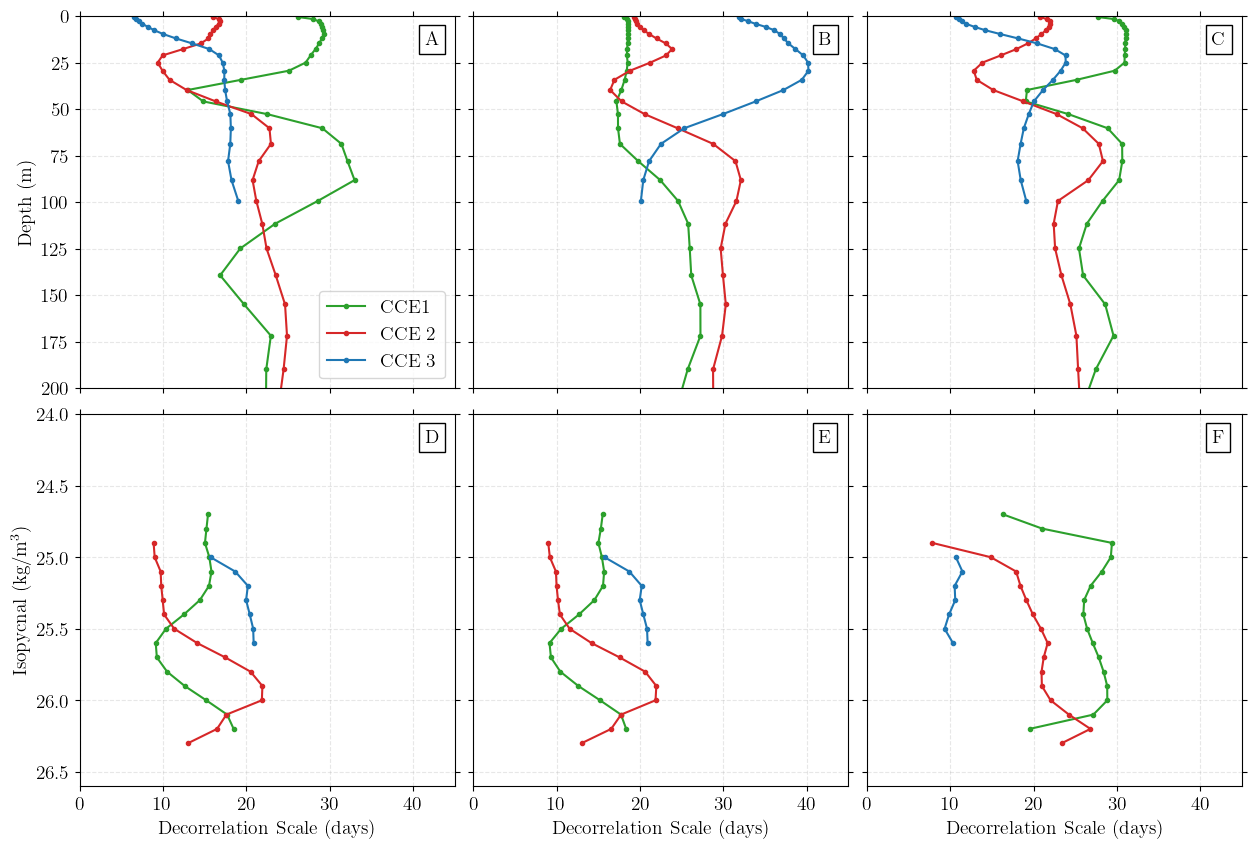

In [8]:
option_data = 'model'

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---# 

# Plot temperature decor scales
if option_data == 'model': 
    ax1.plot(Lt1_temp_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_temp_m,depth_m,'.-', color='tab:red',label='CCE 2')
    ax1.plot(Lt3_temp_m,depth_m,'.-', color='tab:blue',label='CCE 3')
else: 
    ax1.plot(Lt1_temp,depth1,'.-', color='tab:green',label='CCE 1')
    ax1.plot(Lt2_temp,depth2,'.-', color='tab:red',label='CCE 2')

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_xticklabels([])
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend(loc='lower right')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

# Plot absolute salinity decor scales
if option_data == 'model': 
    ax2.plot(Lt1_sal_m,depth_m,'.-', color='tab:green')
    ax2.plot(Lt2_sal_m,depth_m,'.-', color='tab:red')
    ax2.plot(Lt3_sal_m,depth_m,'.-', color='tab:blue')
else: 
    ax2.plot(Lt1_sal,depth1,'.-', color='tab:green')
    ax2.plot(Lt2_sal,depth2,'.-', color='tab:red')

# Set axis attributes
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.set_xlim(0,45)
ax2.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax2.set_yscale('log')
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---# 

# Plot potential density decor scales
if option_data == 'model': 
    ax3.plot(Lt1_rho_m,depth_m,'.-', color='tab:green')
    ax3.plot(Lt2_rho_m,depth_m,'.-', color='tab:red')
    ax3.plot(Lt3_rho_m,depth_m,'.-', color='tab:blue')
else: 
    ax3.plot(Lt1_rho,depth1,'.-', color='tab:green')
    ax3.plot(Lt2_rho,depth2,'.-', color='tab:red')

# Set axis attributes
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.set_xlim(0,45)
ax3.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

# Plot isopycnal temperature decor scales
if option_data == 'model': 
    ax4.plot(Lt1_temp_iso_m,iso1_m,'.-', color='tab:green')
    ax4.plot(Lt2_temp_iso_m,iso2_m,'.-', color='tab:red')
    ax4.plot(Lt3_temp_iso_m,iso3_m,'.-', color='tab:blue')
else: 
    ax4.plot(Lt1_temp_iso,iso1,'.-', color='tab:green')
    ax4.plot(Lt2_temp_iso,iso2,'.-', color='tab:red')

# Set axis attributes
ax4.set_xlabel(r'Decorrelation Scale (days)')
ax4.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax4.set_xlim(0,45)
ax4.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax4.set_yscale('log')
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot isopycnal salinity decor scales
if option_data == 'model': 
    ax5.plot(Lt1_sal_iso_m,iso1_m,'.-', color='tab:green')
    ax5.plot(Lt2_sal_iso_m,iso2_m,'.-', color='tab:red')
    ax5.plot(Lt3_sal_iso_m,iso3_m,'.-', color='tab:blue')
else: 
    ax5.plot(Lt1_sal_iso,iso1,'.-', color='tab:green')
    ax5.plot(Lt2_sal_iso,iso2,'.-', color='tab:red')

# Set axis attributes
ax5.set_xlabel(r'Decorrelation Scale (days)')
ax5.set_yticklabels([])
ax5.set_xlim(0,45)
ax5.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax5.set_yscale('log')
ax5.invert_yaxis()
ax5.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax5.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot isopycnal salinity decor scales
if option_data == 'model': 
    ax6.plot(Lt1_z_iso_m,iso1_m,'.-', color='tab:green')
    ax6.plot(Lt2_z_iso_m,iso2_m,'.-', color='tab:red')
    ax6.plot(Lt3_z_iso_m,iso3_m,'.-', color='tab:blue')
else: 
    ax6.plot(Lt1_z_iso,iso1,'.-', color='tab:green')
    ax6.plot(Lt2_z_iso,iso2,'.-', color='tab:red')

# Set axis attributes
ax6.set_xlabel(r'Decorrelation Scale (days)')
ax6.set_yticklabels([])
ax6.set_xlim(0,45)
ax6.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax6.set_yscale('log')
ax6.invert_yaxis()
ax6.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax6.grid(True,linestyle='--',alpha=0.3)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)

# Show figure
plt.subplots_adjust(hspace=0.07, wspace=0.05)
plt.show()

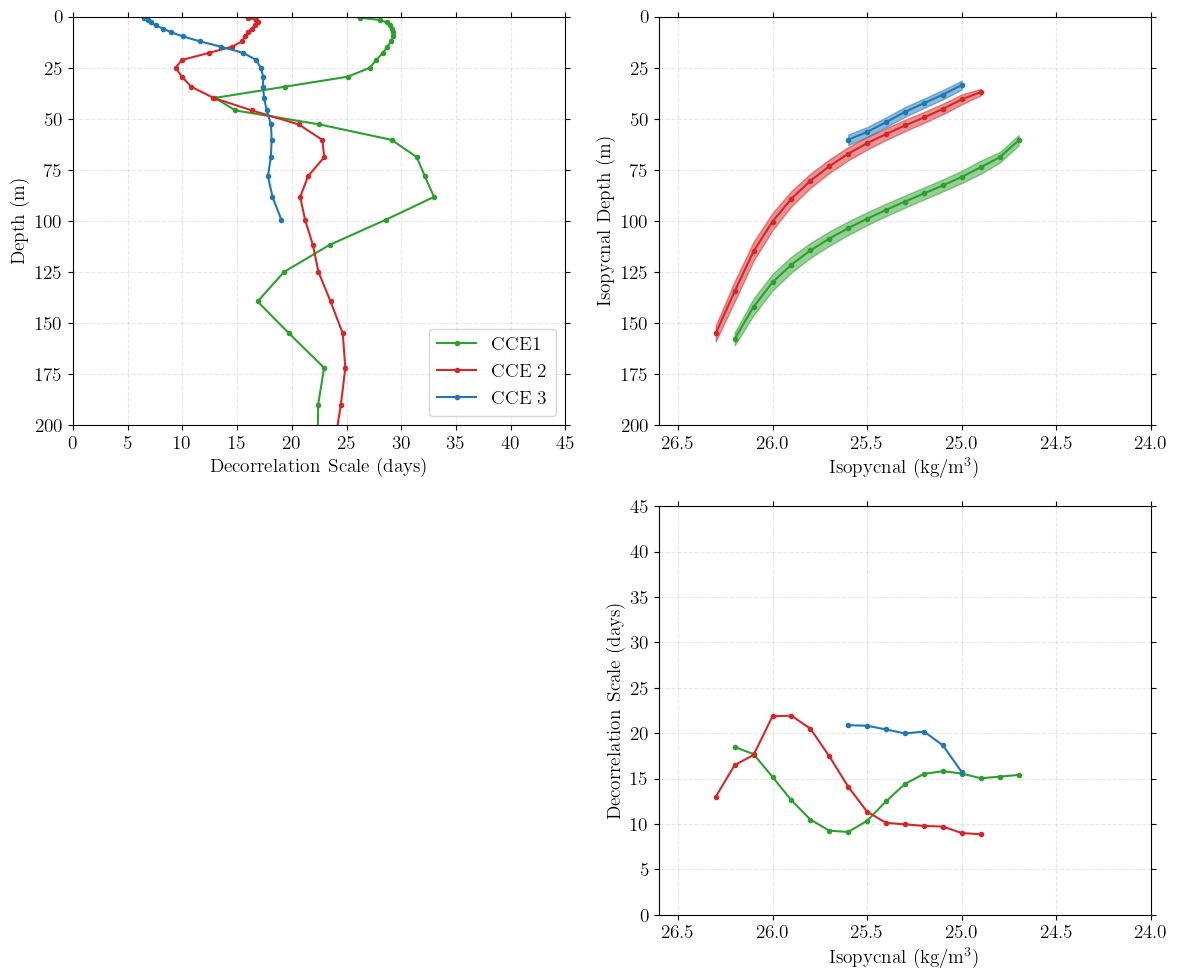

In [9]:
option_data = 'model'

# Create figure
fig,axes = plt.subplots(2,2,figsize=(12, 10))
ax1,ax2,ax3,ax4 = axes.flatten()

#--- Subplot 1 ---# 

# Plot temperature decor scales
if option_data == 'model': 
    ax1.plot(Lt1_temp_m,depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(Lt2_temp_m,depth_m,'.-', color='tab:red',label='CCE 2')
    ax1.plot(Lt3_temp_m,depth_m,'.-', color='tab:blue',label='CCE 3')
else: 
    ax1.plot(Lt1_temp,depth1,'.-', color='tab:green',label='CCE 1')
    ax1.plot(Lt2_temp,depth2,'.-', color='tab:red',label='CCE 2')

# Set axis attributes
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_ylabel("Depth (m)")
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks(np.arange(0,45+5,5))
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend(loc='lower right')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

if option_data == 'model': 
    
    # Plot mean profiles for each mooring
    ax2.plot(iso1_m, abs(meanZ1_iso_m),'.-',color='tab:green',label='CCE 1')
    ax2.plot(iso2_m, abs(meanZ2_iso_m),'.-',color='tab:red',label='CCE 2')
    ax2.plot(iso3_m, abs(meanZ3_iso_m),'.-',color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_between(iso1_m, abs(meanZ1_iso_m - stdmZ1_iso_m), abs(meanZ1_iso_m + stdmZ1_iso_m), color='tab:green', alpha=0.5)
    ax2.fill_between(iso2_m, abs(meanZ2_iso_m - stdmZ2_iso_m), abs(meanZ2_iso_m + stdmZ2_iso_m), color='tab:red', alpha=0.5)
    ax2.fill_between(iso3_m, abs(meanZ3_iso_m - stdmZ3_iso_m), abs(meanZ3_iso_m + stdmZ3_iso_m), color='tab:blue', alpha=0.5)

else: 

    # Plot mean profiles for each mooring
    ax2.plot(iso1, abs(meanZ1_iso),'.-',color='tab:green',label='CCE 1')
    ax2.plot(iso2, abs(meanZ2_iso),'.-',color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_between(iso1, abs(meanZ1_iso - stdmZ1_iso), abs(meanZ1_iso + stdmZ1_iso), color='tab:green', alpha=0.5)
    ax2.fill_between(iso2, abs(meanZ2_iso - stdmZ2_iso), abs(meanZ2_iso + stdmZ2_iso), color='tab:red', alpha=0.5)
    
# Set axis attributes
ax2.set_xlabel(r'Isopycnal (kg/m$^3$)')
ax2.set_ylabel(r'Isopycnal Depth (m)')
ax2.set_xlim(sig_lim[0], sig_lim[1])
ax2.set_ylim(0,200)
if option_log == 1: 
    ax2.set_yscale('log')
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---# 
ax3.axis('off')

#--- Subplot 4 ---# 

# Plot isopycnal temperature decor scales
if option_data == 'model': 
    ax4.plot(iso1_m,Lt1_temp_iso_m,'.-', color='tab:green')
    ax4.plot(iso2_m,Lt2_temp_iso_m,'.-', color='tab:red')
    ax4.plot(iso3_m,Lt3_temp_iso_m,'.-', color='tab:blue')
else: 
    ax4.plot(iso1, Lt1_temp_iso,'.-', color='tab:green')
    ax4.plot(iso2,Lt2_temp_iso,'.-', color='tab:red')

# Set axis attributes
ax4.set_xlabel(r'Isopycnal (kg/m$^3$)')
ax4.set_ylabel(r'Decorrelation Scale (days)')
ax4.set_xlim(sig_lim[0], sig_lim[1])
ax4.set_ylim(0,45)
ax4.set_yticks(np.arange(0,45+5,5))
if option_log == 1: 
    ax4.set_yscale('log')
ax4.invert_xaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

# Adjust spacing
plt.tight_layout()
plt.show()

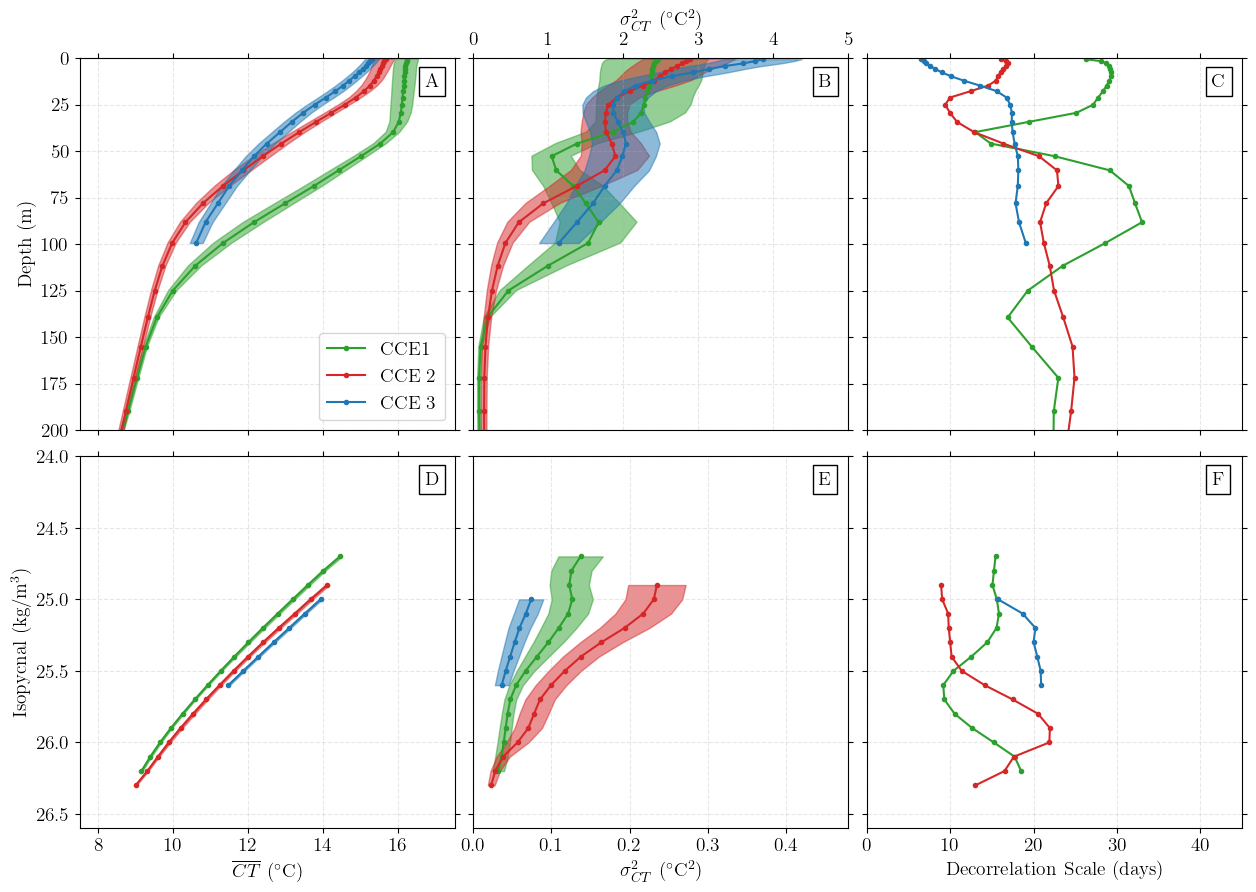

In [10]:
option_data = 'model'

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---# 

# Plot mean temperature profile
if option_data == 'model': 
    ax1.plot(meanTemp_m[0,:],depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(meanTemp_m[1,:],depth_m,'.-', color='tab:red',label='CCE 2')
    ax1.plot(meanTemp_m[2,:],depth_m,'.-', color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax1.fill_betweenx(depth_m, meanTemp_m[0,:] - stdmTemp1_m, meanTemp_m[0,:] + stdmTemp1_m, color='tab:green', alpha=0.5)
    ax1.fill_betweenx(depth_m, meanTemp_m[1,:] - stdmTemp2_m, meanTemp_m[1,:] + stdmTemp2_m, color='tab:red', alpha=0.5)
    ax1.fill_betweenx(depth_m, meanTemp_m[2,:] - stdmTemp3_m, meanTemp_m[2,:] + stdmTemp3_m, color='tab:blue', alpha=0.5)

else: 
    ax1.plot(meanTemp1,depth1,'.-', color='tab:green',label='CCE 1')
    ax1.plot(meanTemp2,depth2,'.-', color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax1.fill_betweenx(depth1, meanTemp1 - stdmTemp1, meanTemp1 + stdmTemp1, color='tab:green', alpha=0.5)
    ax1.fill_betweenx(depth2, meanTemp2 - stdmTemp2, meanTemp2 + stdmTemp2, color='tab:red', alpha=0.5)
    

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_xticklabels([])
ax1.set_xlim(7.5,17.5)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend(loc='lower right')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

# Plot variance profile for temperature
if option_data == 'model': 
    ax2.plot(varTemp_m[0,:],depth_m,'.-', color='tab:green',label='CCE1')
    ax2.plot(varTemp_m[1,:],depth_m,'.-', color='tab:red',label='CCE 2')
    ax2.plot(varTemp_m[2,:],depth_m,'.-', color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(depth_m, varTemp_m[0,:] - stdvTemp1_m, varTemp_m[0,:] + stdvTemp1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(depth_m, varTemp_m[1,:] - stdvTemp2_m, varTemp_m[1,:] + stdvTemp2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(depth_m, varTemp_m[2,:] - stdvTemp3_m, varTemp_m[2,:] + stdvTemp3_m, color='tab:blue', alpha=0.5)

else: 
    ax2.plot(varTemp1,depth1,'.-', color='tab:green',label='CCE 1')
    ax2.plot(varTemp2,depth2,'.-', color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(depth1, varTemp1 - stdvTemp1, varTemp1 + stdvTemp1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(depth2, varTemp2 - stdvTemp2, varTemp2 + stdvTemp2, color='tab:red', alpha=0.5)
    

# Set axis attributes
ax2.set_yticklabels([])
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.tick_params(labeltop=True, top=True, bottom=False, left=True, right=True, direction='out', length=3.5)
ax2.set_xlim(0,5) 
ax2.set_ylim(depth_lim[0], depth_lim[1])
ax2.set_xlabel(r'$\sigma^2_{CT}$ ($^\circ$C$^2$)')
if option_log == 1: 
    ax2.set_yscale('log')
ax2.invert_yaxis()
ax2.grid(True,linestyle='--',alpha=0.3)

# Move ticks to the top
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')

# Turn off bottom ticks if you don’t want them
ax2.tick_params(labeltop=True, top=True, bottom=False)

#--- Subplot 3 ---# 

# Plot temperature decor scales
if option_data == 'model': 
    ax3.plot(Lt1_temp_m,depth_m,'.-', color='tab:green')
    ax3.plot(Lt2_temp_m,depth_m,'.-', color='tab:red')
    ax3.plot(Lt3_temp_m,depth_m,'.-', color='tab:blue')
else: 
    ax3.plot(Lt1_temp,depth1,'.-', color='tab:green')
    ax3.plot(Lt2_temp,depth2,'.-', color='tab:red')

# Set axis attributes
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.set_xlim(0,45)
ax3.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True, 
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

# Plot isopycnal mean temperature profile
if option_data == 'model': 
    ax4.plot(meanTemp1_iso_m,iso1_m,'.-', color='tab:green')
    ax4.plot(meanTemp2_iso_m,iso2_m,'.-', color='tab:red')
    ax4.plot(meanTemp3_iso_m,iso3_m,'.-', color='tab:blue')

    # Plot standard error of the mean profiles for each mooring
    ax4.fill_betweenx(iso1_m, meanTemp1_iso_m - stdmTemp1_iso_m, meanTemp1_iso_m + stdmTemp1_iso_m, color='tab:green', alpha=0.5)
    ax4.fill_betweenx(iso2_m, meanTemp2_iso_m - stdmTemp2_iso_m, meanTemp2_iso_m + stdmTemp2_iso_m, color='tab:red', alpha=0.5)
    ax4.fill_betweenx(iso3_m, meanTemp3_iso_m - stdmTemp3_iso_m, meanTemp3_iso_m + stdmTemp3_iso_m, color='tab:blue', alpha=0.5)

else: 
    ax4.plot(meanTemp1_iso,iso1,'.-', color='tab:green')
    ax4.plot(meanTemp2_iso,iso2,'.-', color='tab:red')

    # Plot standard error of the mean profiles for each mooring
    ax4.fill_betweenx(iso1, meanTemp1_iso - stdmTemp1_iso, meanTemp1_iso + stdmTemp1_iso, color='tab:green', alpha=0.5)
    ax4.fill_betweenx(iso2, meanTemp2_iso - stdmTemp2_iso, meanTemp2_iso + stdmTemp2_iso, color='tab:red', alpha=0.5)
    
# Set axis attributes
ax4.set_xlabel(r'$\overline{CT}$ ($^\circ$C)')
ax4.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax4.set_xlim(7.5,17.5)
ax4.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax4.set_yscale('log')
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot isopycnal mean temperature profile
if option_data == 'model': 
    ax5.plot(varTemp1_iso_m,iso1_m,'.-', color='tab:green')
    ax5.plot(varTemp2_iso_m,iso2_m,'.-', color='tab:red')
    ax5.plot(varTemp3_iso_m,iso3_m,'.-', color='tab:blue')

    # Plot standard error of the mean profiles for each mooring
    ax5.fill_betweenx(iso1_m, varTemp1_iso_m - stdvTemp1_iso_m, varTemp1_iso_m + stdvTemp1_iso_m, color='tab:green', alpha=0.5)
    ax5.fill_betweenx(iso2_m, varTemp2_iso_m - stdvTemp2_iso_m, varTemp2_iso_m + stdvTemp2_iso_m, color='tab:red', alpha=0.5)
    ax5.fill_betweenx(iso3_m, varTemp3_iso_m - stdvTemp3_iso_m, varTemp3_iso_m + stdvTemp3_iso_m, color='tab:blue', alpha=0.5)

else: 
    ax5.plot(varTemp1_iso,iso1,'.-', color='tab:green')
    ax5.plot(varTemp2_iso,iso2,'.-', color='tab:red')

    # Plot standard error of the mean profiles for each mooring
    ax5.fill_betweenx(iso1, varTemp1_iso - stdvTemp1_iso, varTemp1_iso + stdvTemp1_iso, color='tab:green', alpha=0.5)
    ax5.fill_betweenx(iso2, varTemp2_iso - stdvTemp2_iso, varTemp2_iso + stdvTemp2_iso, color='tab:red', alpha=0.5)
    

# Set axis attributes
ax5.set_xlabel(r'$\sigma^2_{CT}$ ($^\circ$C$^2$)')
ax5.set_yticklabels([])
ax5.set_xlim(0,0.48)
ax5.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax5.set_yscale('log')
ax5.invert_yaxis()
ax5.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax5.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot isopycnal salinity decor scales
if option_data == 'model': 
    ax6.plot(Lt1_temp_iso_m,iso1_m,'.-', color='tab:green')
    ax6.plot(Lt2_temp_iso_m,iso2_m,'.-', color='tab:red')
    ax6.plot(Lt3_temp_iso_m,iso3_m,'.-', color='tab:blue')
else: 
    ax6.plot(Lt1_temp_iso,iso1,'.-', color='tab:green')
    ax6.plot(Lt2_temp_iso,iso2,'.-', color='tab:red')

# Set axis attributes
ax6.set_xlabel(r'Decorrelation Scale (days)')
ax6.set_yticklabels([])
ax6.set_xlim(0,45)
ax6.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax6.set_yscale('log')
ax6.invert_yaxis()
ax6.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax6.grid(True,linestyle='--',alpha=0.3)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)

# Show figure
plt.subplots_adjust(hspace=0.07, wspace=0.05)
plt.show()

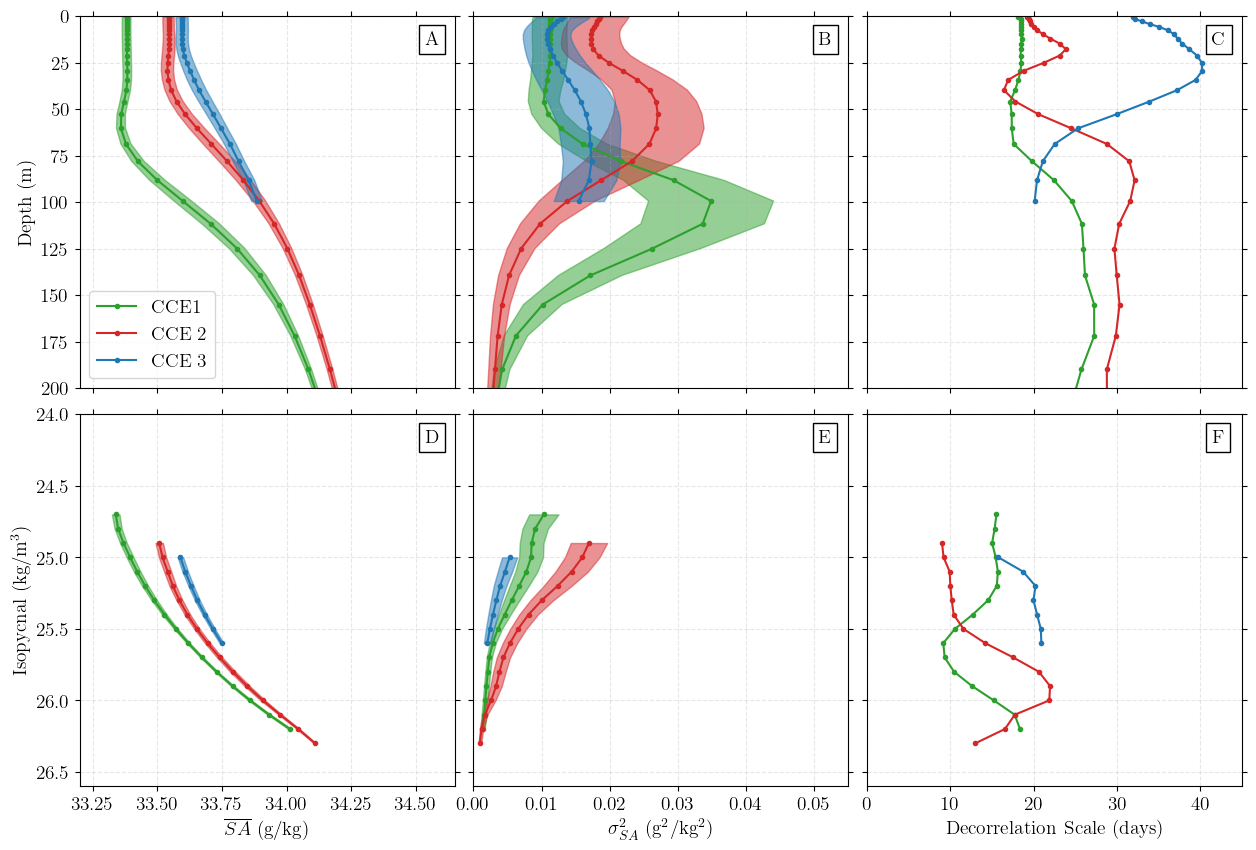

In [11]:
option_data = 'model'

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---# 

# Plot mean Salinity profile
if option_data == 'model': 
    ax1.plot(meanSal_m[0,:],depth_m,'.-', color='tab:green',label='CCE1')
    ax1.plot(meanSal_m[1,:],depth_m,'.-', color='tab:red',label='CCE 2')
    ax1.plot(meanSal_m[2,:],depth_m,'.-', color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax1.fill_betweenx(depth_m, meanSal_m[0,:] - stdmSal1_m, meanSal_m[0,:] + stdmSal1_m, color='tab:green', alpha=0.5)
    ax1.fill_betweenx(depth_m, meanSal_m[1,:] - stdmSal2_m, meanSal_m[1,:] + stdmSal2_m, color='tab:red', alpha=0.5)
    ax1.fill_betweenx(depth_m, meanSal_m[2,:] - stdmSal3_m, meanSal_m[2,:] + stdmSal3_m, color='tab:blue', alpha=0.5)

else: 
    ax1.plot(meanSal1,depth1,'.-', color='tab:green',label='CCE 1')
    ax1.plot(meanSal2,depth2,'.-', color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax1.fill_betweenx(depth1, meanSal1 - stdmSal1, meanSal1 + stdmSal1, color='tab:green', alpha=0.5)
    ax1.fill_betweenx(depth2, meanSal2 - stdmSal2, meanSal2 + stdmSal2, color='tab:red', alpha=0.5)
    
# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_xticklabels([])
ax1.set_xlim(33.2,34.65)
ax1.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax1.set_yscale('log')
ax1.invert_yaxis()
ax1.legend(loc='lower left')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---# 

# Plot variance profile for temperature
if option_data == 'model': 
    ax2.plot(varSal_m[0,:],depth_m,'.-', color='tab:green',label='CCE1')
    ax2.plot(varSal_m[1,:],depth_m,'.-', color='tab:red',label='CCE 2')
    ax2.plot(varSal_m[2,:],depth_m,'.-', color='tab:blue',label='CCE 3')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(depth_m, varSal_m[0,:] - stdvSal1_m, varSal_m[0,:] + stdvSal1_m, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(depth_m, varSal_m[1,:] - stdvSal2_m, varSal_m[1,:] + stdvSal2_m, color='tab:red', alpha=0.5)
    ax2.fill_betweenx(depth_m, varSal_m[2,:] - stdvSal3_m, varSal_m[2,:] + stdvSal3_m, color='tab:blue', alpha=0.5)

else: 
    ax2.plot(varSal1,depth1,'.-', color='tab:green',label='CCE 1')
    ax2.plot(varSal2,depth2,'.-', color='tab:red',label='CCE 2')

    # Plot standard error of the mean profiles for each mooring
    ax2.fill_betweenx(depth1, varSal1 - stdvSal1, varSal1 + stdvSal1, color='tab:green', alpha=0.5)
    ax2.fill_betweenx(depth2, varSal2 - stdvSal2, varSal2 + stdvSal2, color='tab:red', alpha=0.5)
    

# Set axis attributes
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.set_xlim(0,0.055) 
ax2.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax2.set_yscale('log')
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---# 

# Plot Saliity decor scales
if option_data == 'model': 
    ax3.plot(Lt1_sal_m,depth_m,'.-', color='tab:green')
    ax3.plot(Lt2_sal_m,depth_m,'.-', color='tab:red')
    ax3.plot(Lt3_sal_m,depth_m,'.-', color='tab:blue')
else: 
    ax3.plot(Lt1_sal,depth1,'.-', color='tab:green')
    ax3.plot(Lt2_sal,depth2,'.-', color='tab:red')

# Set axis attributes
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.set_xlim(0,45)
ax3.set_ylim(depth_lim[0], depth_lim[1])
if option_log == 1: 
    ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True, 
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

# Plot isopycnal mean temperature profile
if option_data == 'model': 
    ax4.plot(meanSal1_iso_m,iso1_m,'.-', color='tab:green')
    ax4.plot(meanSal2_iso_m,iso2_m,'.-', color='tab:red')
    ax4.plot(meanSal3_iso_m,iso3_m,'.-', color='tab:blue')

    # Plot standard error of the mean profiles for each mooring
    ax4.fill_betweenx(iso1_m, meanSal1_iso_m - stdmSal1_iso_m, meanSal1_iso_m + stdmSal1_iso_m, color='tab:green', alpha=0.5)
    ax4.fill_betweenx(iso2_m, meanSal2_iso_m - stdmSal2_iso_m, meanSal2_iso_m + stdmSal2_iso_m, color='tab:red', alpha=0.5)
    ax4.fill_betweenx(iso3_m, meanSal3_iso_m - stdmSal3_iso_m, meanSal3_iso_m + stdmSal3_iso_m, color='tab:blue', alpha=0.5)

else: 
    ax4.plot(meanSal1_iso,iso1,'.-', color='tab:green')
    ax4.plot(meanSal2_iso,iso2,'.-', color='tab:red')

    # Plot standard error of the mean profiles for each mooring
    ax4.fill_betweenx(iso1, meanSal1_iso - stdmSal1_iso, meanSal1_iso + stdmSal1_iso, color='tab:green', alpha=0.5)
    ax4.fill_betweenx(iso2, meanSal2_iso - stdmSal2_iso, meanSal2_iso + stdmSal2_iso, color='tab:red', alpha=0.5)
    
# Set axis attributes
ax4.set_xlabel(r'$\overline{SA}$ (g/kg)')
ax4.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax4.set_xlim(33.2,34.65)
ax4.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax4.set_yscale('log')
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot isopycnal mean temperature profile
if option_data == 'model': 
    ax5.plot(varSal1_iso_m,iso1_m,'.-', color='tab:green')
    ax5.plot(varSal2_iso_m,iso2_m,'.-', color='tab:red')
    ax5.plot(varSal3_iso_m,iso3_m,'.-', color='tab:blue')

    # Plot standard error of the mean profiles for each mooring
    ax5.fill_betweenx(iso1_m, varSal1_iso_m - stdvSal1_iso_m, varSal1_iso_m + stdvSal1_iso_m, color='tab:green', alpha=0.5)
    ax5.fill_betweenx(iso2_m, varSal2_iso_m - stdvSal2_iso_m, varSal2_iso_m + stdvSal2_iso_m, color='tab:red', alpha=0.5)
    ax5.fill_betweenx(iso3_m, varSal3_iso_m - stdvSal3_iso_m, varSal3_iso_m + stdvSal3_iso_m, color='tab:blue', alpha=0.5)

else: 
    ax5.plot(varSal1_iso,iso1,'.-', color='tab:green')
    ax5.plot(varSal2_iso,iso2,'.-', color='tab:red')

    # Plot standard error of the mean profiles for each mooring
    ax5.fill_betweenx(iso1, varSal1_iso - stdvSal1_iso, varSal1_iso + stdvSal1_iso, color='tab:green', alpha=0.5)
    ax5.fill_betweenx(iso2, varSal2_iso - stdvSal2_iso, varSal2_iso + stdvSal2_iso, color='tab:red', alpha=0.5)
    

# Set axis attributes
ax5.set_xlabel(r'$\sigma^2_{SA}$ (g$^2$/kg$^2$)')
ax5.set_yticklabels([])
ax5.set_xlim(0,0.055)
ax5.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax5.set_yscale('log')
ax5.invert_yaxis()
ax5.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax5.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot isopycnal salinity decor scales
if option_data == 'model': 
    ax6.plot(Lt1_sal_iso_m,iso1_m,'.-', color='tab:green')
    ax6.plot(Lt2_sal_iso_m,iso2_m,'.-', color='tab:red')
    ax6.plot(Lt3_sal_iso_m,iso3_m,'.-', color='tab:blue')
else: 
    ax6.plot(Lt1_sal_iso,iso1,'.-', color='tab:green')
    ax6.plot(Lt2_sal_iso,iso2,'.-', color='tab:red')

# Set axis attributes
ax6.set_xlabel(r'Decorrelation Scale (days)')
ax6.set_yticklabels([])
ax6.set_xlim(0,45)
ax6.set_ylim(sig_lim[0], sig_lim[1])
if option_log == 1: 
    ax6.set_yscale('log')
ax6.invert_yaxis()
ax6.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax6.grid(True,linestyle='--',alpha=0.3)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)

# Show figure
plt.subplots_adjust(hspace=0.07, wspace=0.05)
plt.show()

In [12]:
# Compute the equivalent temporal frequency of the decorrelation scale
f1_temp_decor_m = (1/Lt1_temp_m)*(2*np.pi)
f2_temp_decor_m = (1/Lt2_temp_m)*(2*np.pi)
f3_temp_decor_m = (1/Lt3_temp_m)*(2*np.pi)
f1_temp_decor   = (1/Lt1_temp)*(2*np.pi)
f2_temp_decor   = (1/Lt2_temp)*(2*np.pi)

f1_temp_decor_iso_m = (1/Lt1_temp_iso_m)*(2*np.pi)
f2_temp_decor_iso_m = (1/Lt2_temp_iso_m)*(2*np.pi)
f3_temp_decor_iso_m = (1/Lt3_temp_iso_m)*(2*np.pi)
f1_temp_decor_iso   = (1/Lt1_temp_iso)*(2*np.pi)
f2_temp_decor_iso   = (1/Lt2_temp_iso)*(2*np.pi)

# Compute the period of the equivalent decorrelation temporal frequency
T1_temp_decor_m = 1/f1_temp_decor_m
T2_temp_decor_m = 1/f2_temp_decor_m
T3_temp_decor_m = 1/f3_temp_decor_m
T1_temp_decor = 1/f1_temp_decor
T2_temp_decor = 1/f2_temp_decor

T1_temp_decor_iso_m = 1/f1_temp_decor_iso_m
T2_temp_decor_iso_m = 1/f2_temp_decor_iso_m
T3_temp_decor_iso_m = 1/f3_temp_decor_iso_m
T1_temp_decor_iso = 1/f1_temp_decor_iso
T2_temp_decor_iso = 1/f2_temp_decor_iso

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/2152731578.py:27: RuntimeWarning: divide by zero encountered in log10
  pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_temp_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/2152731578.py:56: RuntimeWarning: divide by zero encountered in log10
  pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_temp_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/2152731578.py:84: RuntimeWarning: divide by zero encountered in log10
  pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_temp_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/2152731578.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


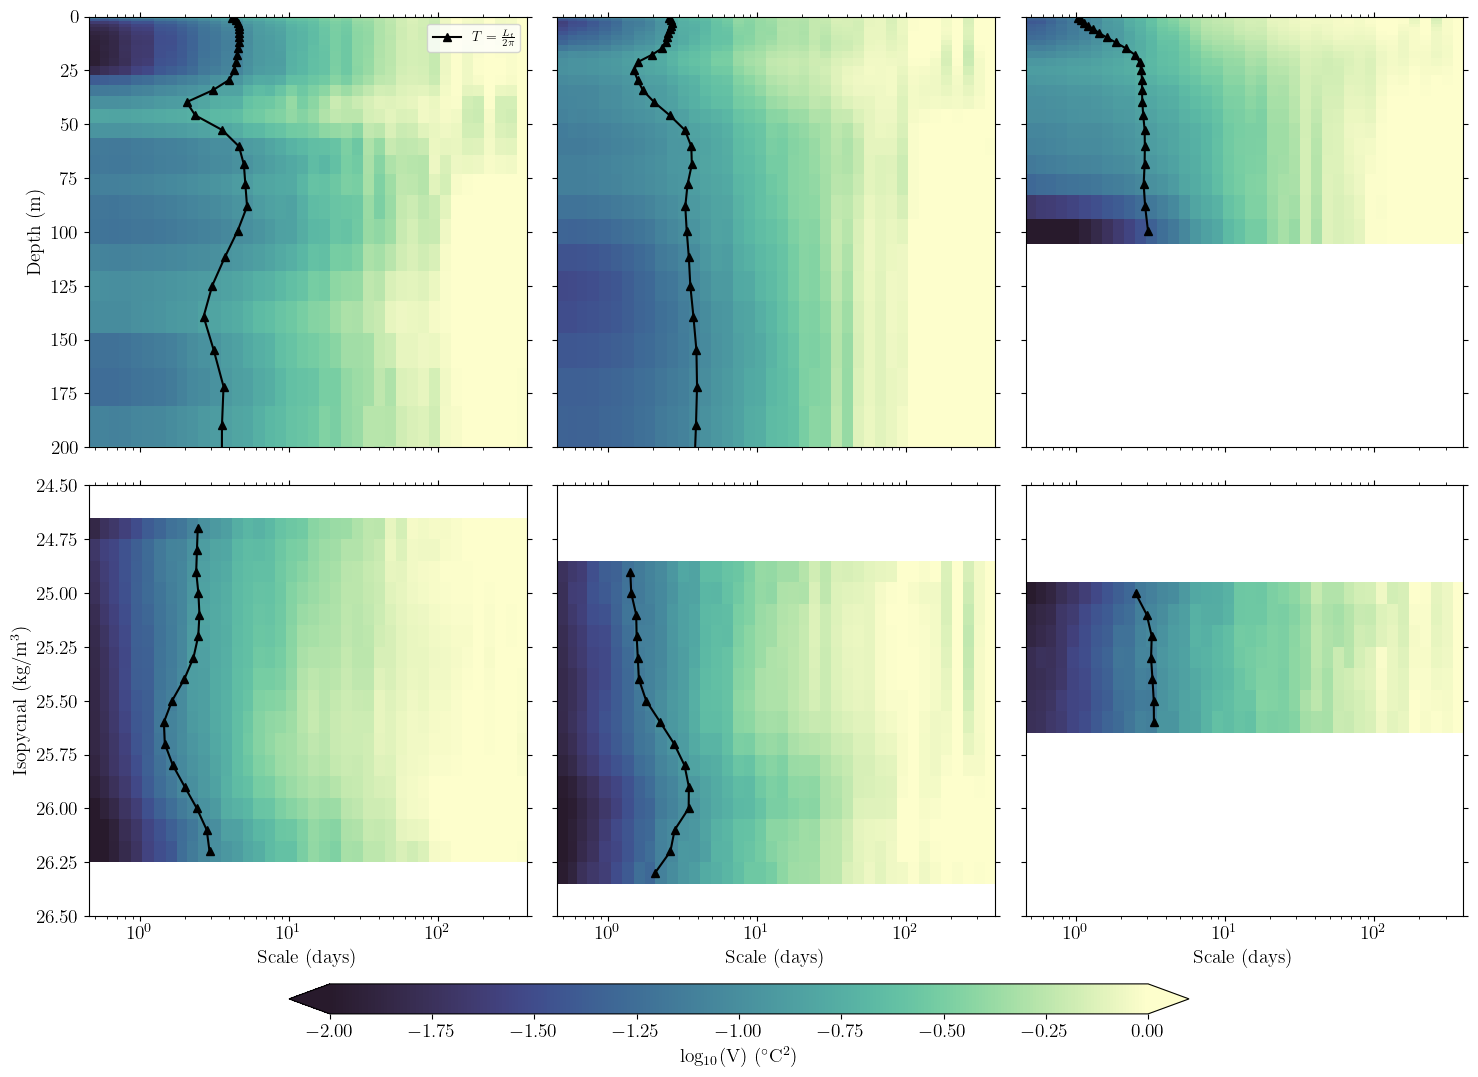

In [13]:
option_data = 'model'

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create meshgrid 
SC_m, D_m = np.meshgrid(L_m[:,0]*(1/24), depth_m) 
SC1, D1 = np.meshgrid(L1_temp[:,0]*(1/24), depth1) 
SC2, D2 = np.meshgrid(L2_temp[:,0]*(1/24), depth2) 

SC_iso1_m, D_iso1_m = np.meshgrid(L1_temp_iso_m[:,0]*(1/24), iso1_m)
SC_iso2_m, D_iso2_m = np.meshgrid(L2_temp_iso_m[:,0]*(1/24), iso2_m)
SC_iso3_m, D_iso3_m = np.meshgrid(L3_temp_iso_m[:,0]*(1/24), iso3_m)
SC_iso1, D_iso1 = np.meshgrid(L1_temp_iso[:,0]*(1/24), iso1)
SC_iso2, D_iso2 = np.meshgrid(L2_temp_iso[:,0]*(1/24), iso2)

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_temp_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_temp_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax1.pcolormesh(SC1,D1,np.log10(V1_temp.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_temp_decor, depth1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(0,200)
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)
ax1.legend(loc='upper right',fontsize=10)
ax1.invert_yaxis() 

#--- Subplot 2 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_temp_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_temp_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else:

    # Plot scale variance 
    pc = ax2.pcolormesh(SC2,D2,np.log10(V2_temp.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_temp_decor, depth2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax2.set_yticklabels([])
ax2.set_ylim(0,200)
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)
ax2.invert_yaxis()

#--- Subplot 3 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_temp_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax3.plot(T3_temp_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax3.set_yticklabels([])
    ax3.set_ylim(0,200)
    ax3.set_xscale('log')
    ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
    ax3.tick_params(which='major', length=3.5)
    ax3.tick_params(which='minor', length=2.5)
    ax3.invert_yaxis()

else: 

    ax3.axis('off')

#--- Subplot 4 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax4.pcolormesh(SC_iso1_m,D_iso1_m,np.log10(V1_temp_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax4.plot(T1_temp_decor_iso_m, iso1_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else:

    # Plot scale variance 
    pc = ax4.pcolormesh(SC_iso1,D_iso1,np.log10(V1_temp_iso.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax4.plot(T1_temp_decor_iso, iso1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')    

# Set figure attributes
ax4.set_xlabel('Scale (days)')
ax4.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax4.set_ylim(24.5, 26.5)
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)
ax4.invert_yaxis()

#--- Subplot 5 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax5.pcolormesh(SC_iso2_m,D_iso2_m,np.log10(V2_temp_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax5.plot(T2_temp_decor_iso_m, iso2_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax5.pcolormesh(SC_iso2,D_iso2,np.log10(V2_temp_iso.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax5.plot(T2_temp_decor_iso, iso2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax5.set_yticklabels([])
ax5.set_xlabel('Scale (days)')
ax5.set_ylim(24.5, 26.5)
ax5.set_xscale('log')
ax5.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax5.tick_params(which='major', length=3.5)
ax5.tick_params(which='minor', length=2.5)
ax5.invert_yaxis()

#--- Subplot 6 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax6.pcolormesh(SC_iso3_m,D_iso3_m,np.log10(V3_temp_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax6.plot(T3_temp_decor_iso_m, iso3_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax6.set_yticklabels([])
    ax6.set_xlabel('Scale (days)')
    ax6.set_ylim(24.5, 26.5)
    ax6.set_xscale('log')
    ax6.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
    ax6.tick_params(which='major', length=3.5)
    ax6.tick_params(which='minor', length=2.5)
    ax6.invert_yaxis()

else:

    ax6.axis('off')

# Set color bar
cax = fig.add_axes([0.20, -0.025, 0.6, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'log$_{10}$(V) ($^\circ$C$^2$)')

# Display figure
plt.tight_layout()
plt.show()

In [14]:
# Compute the equivalent temporal frequency of the decorrelation scale
f1_sal_decor_m = (1/Lt1_sal_m)*(2*np.pi)
f2_sal_decor_m = (1/Lt2_sal_m)*(2*np.pi)
f3_sal_decor_m = (1/Lt3_sal_m)*(2*np.pi)
f1_sal_decor   = (1/Lt1_sal)*(2*np.pi)
f2_sal_decor   = (1/Lt2_sal)*(2*np.pi)

f1_sal_decor_iso_m = (1/Lt1_sal_iso_m)*(2*np.pi)
f2_sal_decor_iso_m = (1/Lt2_sal_iso_m)*(2*np.pi)
f3_sal_decor_iso_m = (1/Lt3_sal_iso_m)*(2*np.pi)
f1_sal_decor_iso   = (1/Lt1_sal_iso)*(2*np.pi)
f2_sal_decor_iso   = (1/Lt2_sal_iso)*(2*np.pi)

# Compute the period of the equivalent decorrelation temporal frequency
T1_sal_decor_m = 1/f1_sal_decor_m
T2_sal_decor_m = 1/f2_sal_decor_m
T3_sal_decor_m = 1/f3_sal_decor_m
T1_sal_decor = 1/f1_sal_decor
T2_sal_decor = 1/f2_sal_decor

T1_sal_decor_iso_m = 1/f1_sal_decor_iso_m
T2_sal_decor_iso_m = 1/f2_sal_decor_iso_m
T3_sal_decor_iso_m = 1/f3_sal_decor_iso_m
T1_sal_decor_iso = 1/f1_sal_decor_iso
T2_sal_decor_iso = 1/f2_sal_decor_iso

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3419559123.py:27: RuntimeWarning: divide by zero encountered in log10
  pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_sal_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3419559123.py:56: RuntimeWarning: divide by zero encountered in log10
  pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_sal_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3419559123.py:84: RuntimeWarning: divide by zero encountered in log10
  pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_sal_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3419559123.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


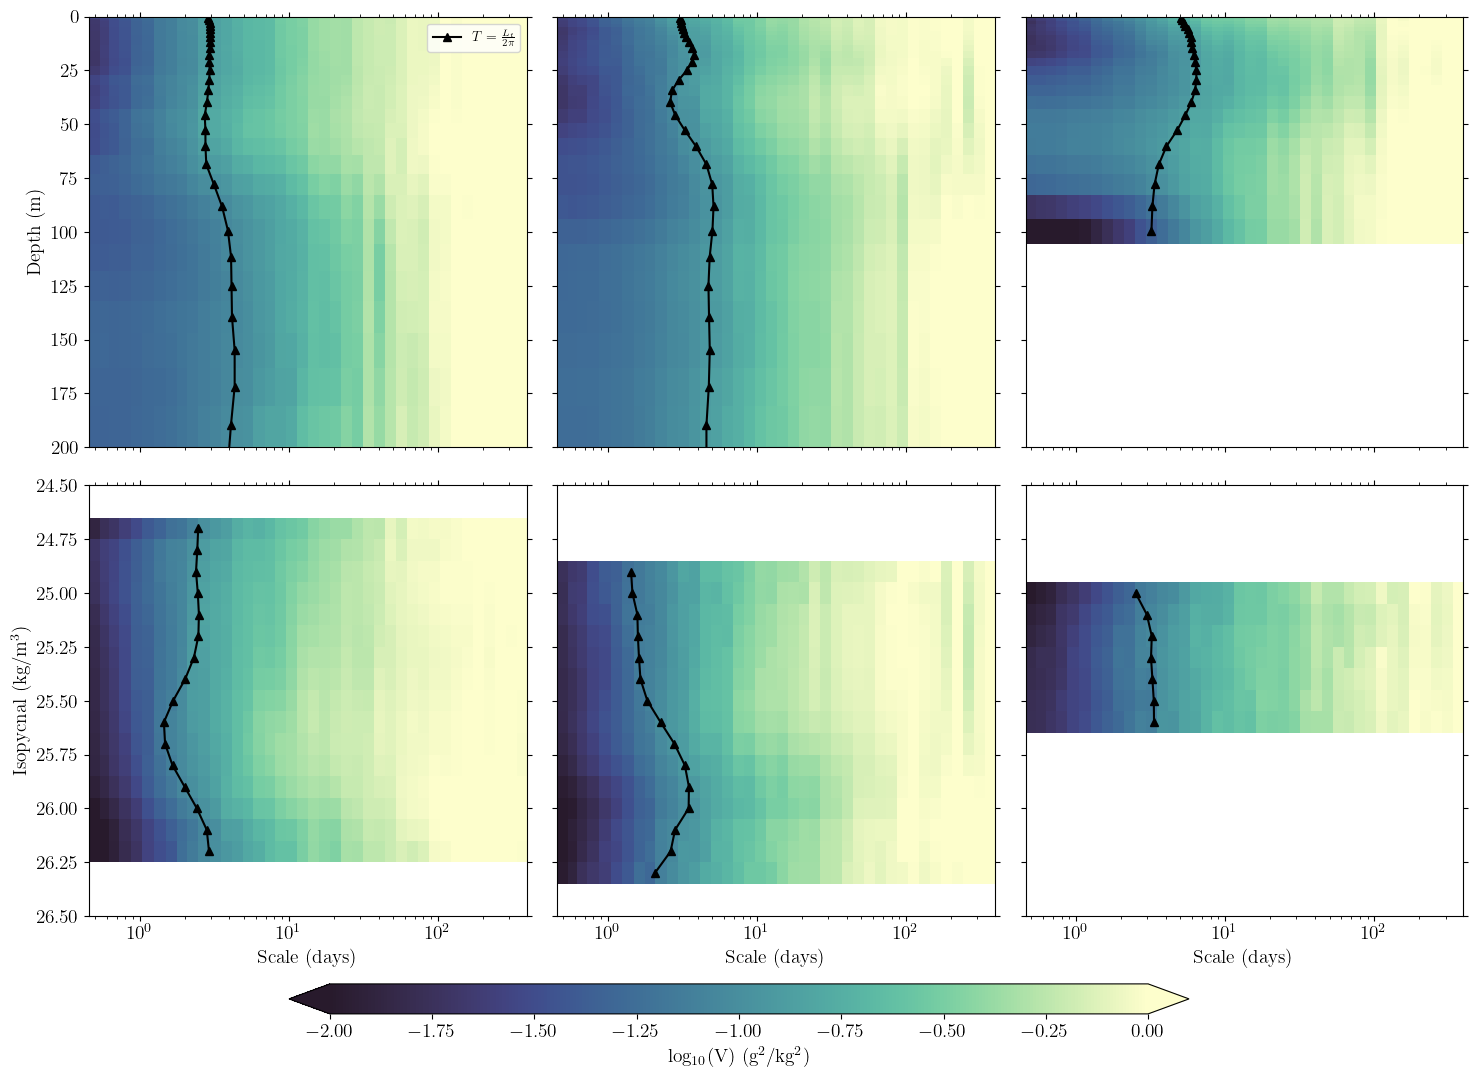

In [15]:
option_data = 'model'

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create meshgrid 
SC_m, D_m = np.meshgrid(L_m[:,0]*(1/24), depth_m) 
SC1, D1 = np.meshgrid(L1_sal[:,0]*(1/24), depth1) 
SC2, D2 = np.meshgrid(L2_sal[:,0]*(1/24), depth2) 

SC_iso1_m, D_iso1_m = np.meshgrid(L1_sal_iso_m[:,0]*(1/24), iso1_m)
SC_iso2_m, D_iso2_m = np.meshgrid(L2_sal_iso_m[:,0]*(1/24), iso2_m)
SC_iso3_m, D_iso3_m = np.meshgrid(L3_sal_iso_m[:,0]*(1/24), iso3_m)
SC_iso1, D_iso1 = np.meshgrid(L1_sal_iso[:,0]*(1/24), iso1)
SC_iso2, D_iso2 = np.meshgrid(L2_sal_iso[:,0]*(1/24), iso2)

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_sal_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_sal_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax1.pcolormesh(SC1,D1,np.log10(V1_sal.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_sal_decor, depth1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(0,200)
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)
ax1.legend(loc='upper right',fontsize=10)
ax1.invert_yaxis() 

#--- Subplot 2 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_sal_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_sal_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax2.pcolormesh(SC2,D2,np.log10(V2_sal.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_sal_decor, depth2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax2.set_yticklabels([])
ax2.set_ylim(0,200)
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)
ax2.invert_yaxis()

#--- Subplot 3 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_sal_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax3.plot(T3_sal_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax3.set_yticklabels([])
    ax3.set_ylim(0,200)
    ax3.set_xscale('log')
    ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
    ax3.tick_params(which='major', length=3.5)
    ax3.tick_params(which='minor', length=2.5)
    ax3.invert_yaxis()

else: 

    ax3.axis('off')

#--- Subplot 4 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax4.pcolormesh(SC_iso1_m,D_iso1_m,np.log10(V1_sal_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax4.plot(T1_sal_decor_iso_m, iso1_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax4.pcolormesh(SC_iso1,D_iso1,np.log10(V1_sal_iso.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax4.plot(T1_sal_decor_iso, iso1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax4.set_xlabel('Scale (days)')
ax4.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax4.set_ylim(24.5, 26.5)
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)
ax4.invert_yaxis()

#--- Subplot 5 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax5.pcolormesh(SC_iso2_m,D_iso2_m,np.log10(V2_sal_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax5.plot(T2_sal_decor_iso_m, iso2_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax5.pcolormesh(SC_iso2,D_iso2,np.log10(V2_sal_iso.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax5.plot(T2_sal_decor_iso, iso2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax5.set_yticklabels([])
ax5.set_xlabel('Scale (days)')
ax5.set_ylim(24.5, 26.5)
ax5.set_xscale('log')
ax5.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax5.tick_params(which='major', length=3.5)
ax5.tick_params(which='minor', length=2.5)
ax5.invert_yaxis()

#--- Subplot 6 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax6.pcolormesh(SC_iso3_m,D_iso3_m,np.log10(V3_sal_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax6.plot(T3_sal_decor_iso_m, iso3_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax6.set_yticklabels([])
    ax6.set_xlabel('Scale (days)')
    ax6.set_ylim(24.5, 26.5)
    ax6.set_xscale('log')
    ax6.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
    ax6.tick_params(which='major', length=3.5)
    ax6.tick_params(which='minor', length=2.5)
    ax6.invert_yaxis()

else: 

    ax6.axis('off')

# Set color bar
cax = fig.add_axes([0.20, -0.025, 0.6, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'log$_{10}$(V) (g$^2$/kg$^2$)')

# Display figure
plt.tight_layout()
plt.show()

In [30]:
# Compute the equivalent temporal frequency of the decorrelation scale
f1_rho_decor_m = (1/Lt1_rho_m)*(2*np.pi)
f2_rho_decor_m = (1/Lt2_rho_m)*(2*np.pi)
f3_rho_decor_m = (1/Lt3_rho_m)*(2*np.pi)
f1_rho_decor   = (1/Lt1_rho)*(2*np.pi)
f2_rho_decor   = (1/Lt2_rho)*(2*np.pi)

f1_z_decor_iso_m = (1/Lt1_z_iso_m)*(2*np.pi)
f2_z_decor_iso_m = (1/Lt2_z_iso_m)*(2*np.pi)
f3_z_decor_iso_m = (1/Lt3_z_iso_m)*(2*np.pi)
f1_z_decor_iso   = (1/Lt1_z_iso)*(2*np.pi)
f2_z_decor_iso   = (1/Lt2_z_iso)*(2*np.pi)

# Compute the period of the equivalent decorrelation temporal frequency
T1_rho_decor_m = 1/f1_rho_decor_m
T2_rho_decor_m = 1/f2_rho_decor_m
T3_rho_decor_m = 1/f3_rho_decor_m
T1_rho_decor = 1/f1_rho_decor
T2_rho_decor = 1/f2_rho_decor

T1_z_decor_iso_m = 1/f1_z_decor_iso_m
T2_z_decor_iso_m = 1/f2_z_decor_iso_m
T3_z_decor_iso_m = 1/f3_z_decor_iso_m
T1_z_decor_iso = 1/f1_z_decor_iso
T2_z_decor_iso = 1/f2_z_decor_iso

# Compute the rotation rate of earth
omega = (7.2921*10**(-5))/(2*np.pi)              # Units: Hz 

# Compute the interial frequency at each mooring in units of cpd
f1_i = 2*omega*np.sin(np.deg2rad(lat1)) * (86400)  # Units: cpd
f2_i = 2*omega*np.sin(np.deg2rad(lat2)) * (86400)
f3_i = 2*omega*np.sin(np.deg2rad(lat1)) * (86400)

# Compute the tidal frequencies (M2, K1) in cpd
T_m2 = 12.42 * (1/24)           # Units: days
T_k1 = 23.93 * (1/24)           # Units: days
f_m2 = 1 / T_m2
f_k1 = 1 / T_k1

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/1218541140.py:27: RuntimeWarning: divide by zero encountered in log10
  pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/1218541140.py:56: RuntimeWarning: divide by zero encountered in log10
  pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/1218541140.py:84: RuntimeWarning: divide by zero encountered in log10
  pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/1218541140.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


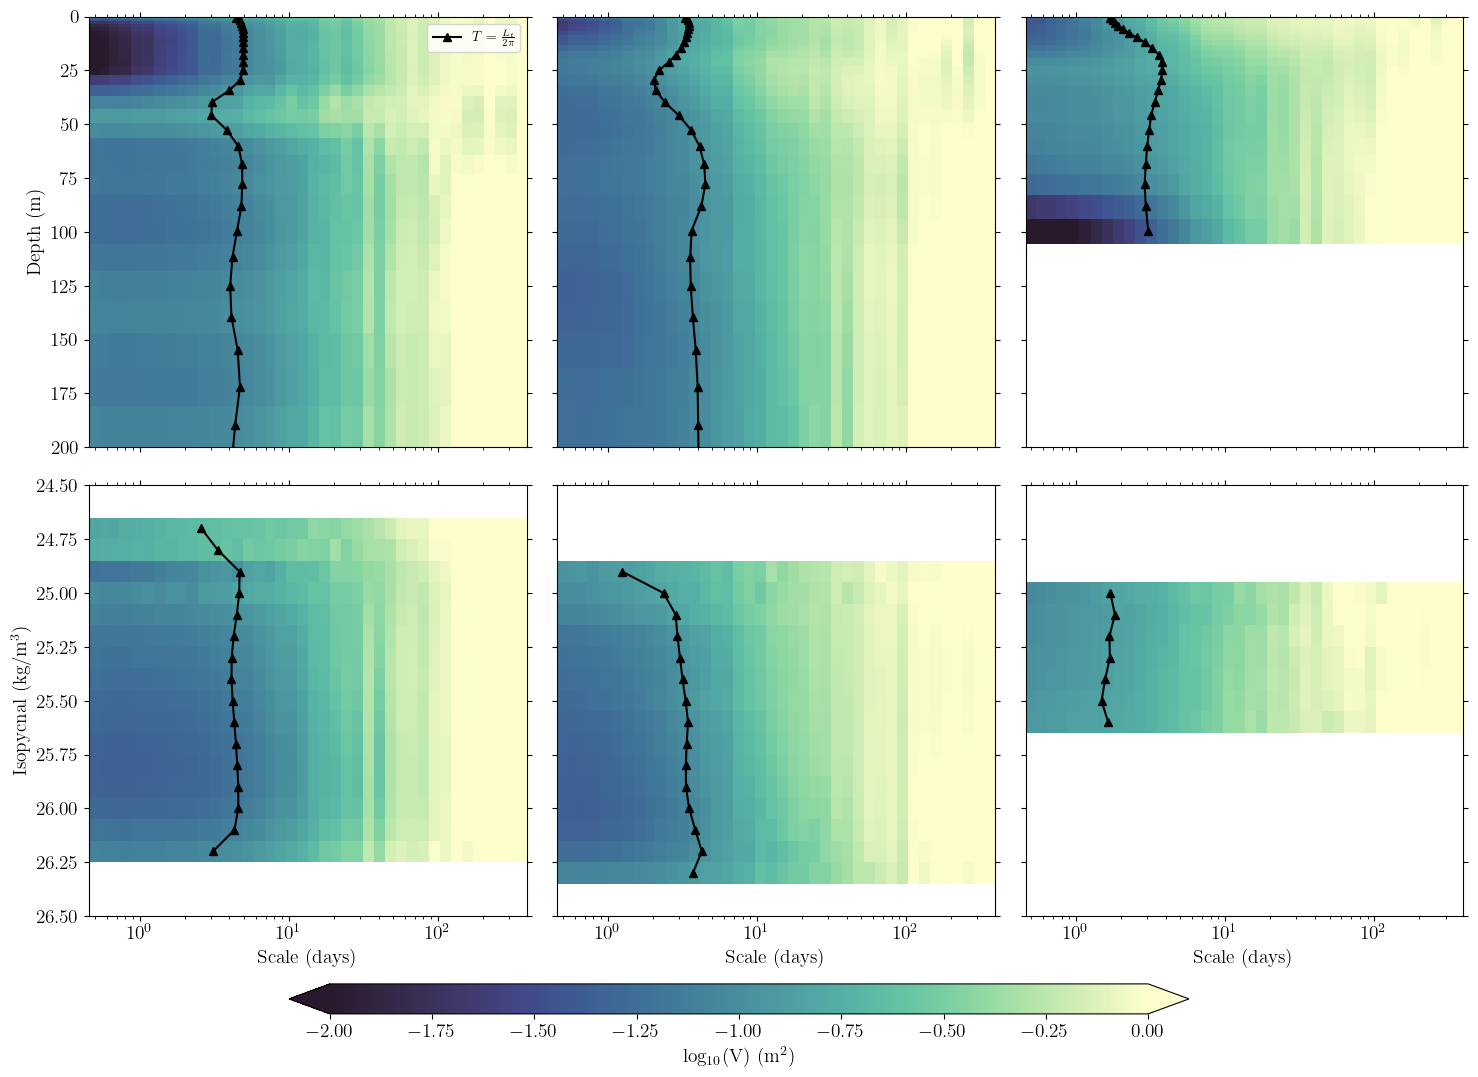

In [29]:
option_data = 'model'

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create meshgrid 
SC_m, D_m = np.meshgrid(L_m[:,0]*(1/24), depth_m) 
SC1, D1 = np.meshgrid(L1_rho[:,0]*(1/24), depth1) 
SC2, D2 = np.meshgrid(L2_rho[:,0]*(1/24), depth2) 

SC_iso1_m, D_iso1_m = np.meshgrid(L1_z_iso_m[:,0]*(1/24), iso1_m)
SC_iso2_m, D_iso2_m = np.meshgrid(L2_z_iso_m[:,0]*(1/24), iso2_m)
SC_iso3_m, D_iso3_m = np.meshgrid(L3_z_iso_m[:,0]*(1/24), iso3_m)
SC_iso1, D_iso1 = np.meshgrid(L1_z_iso[:,0]*(1/24), iso1)
SC_iso2, D_iso2 = np.meshgrid(L2_z_iso[:,0]*(1/24), iso2)

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_rho_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax1.pcolormesh(SC1,D1,np.log10(V1_rho.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_rho_decor, depth1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(0,200)
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)
ax1.legend(loc='upper right',fontsize=10)
ax1.invert_yaxis() 

#--- Subplot 2 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_rho_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax2.pcolormesh(SC2,D2,np.log10(V2_rho.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_rho_decor, depth2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax2.set_yticklabels([])
ax2.set_ylim(0,200)
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)
ax2.invert_yaxis()

#--- Subplot 3 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax3.plot(T3_rho_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax3.set_yticklabels([])
    ax3.set_ylim(0,200)
    ax3.set_xscale('log')
    ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
    ax3.tick_params(which='major', length=3.5)
    ax3.tick_params(which='minor', length=2.5)
    ax3.invert_yaxis()

else: 

    ax3.axis('off')

#--- Subplot 4 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax4.pcolormesh(SC_iso1_m,D_iso1_m,np.log10(V1_z_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax4.plot(T1_z_decor_iso_m, iso1_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax4.pcolormesh(SC_iso1,D_iso1,np.log10(V1_z_iso.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax4.plot(T1_z_decor_iso, iso1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax4.set_xlabel('Scale (days)')
ax4.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax4.set_ylim(24.5, 26.5)
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)
ax4.invert_yaxis()

#--- Subplot 5 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax5.pcolormesh(SC_iso2_m,D_iso2_m,np.log10(V2_z_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax5.plot(T2_z_decor_iso_m, iso2_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax5.pcolormesh(SC_iso2,D_iso2,np.log10(V2_z_iso.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax5.plot(T2_z_decor_iso, iso2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax5.set_yticklabels([])
ax5.set_xlabel('Scale (days)')
ax5.set_ylim(24.5, 26.5)
ax5.set_xscale('log')
ax5.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax5.tick_params(which='major', length=3.5)
ax5.tick_params(which='minor', length=2.5)
ax5.invert_yaxis()

#--- Subplot 6 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax6.pcolormesh(SC_iso3_m,D_iso3_m,np.log10(V3_z_iso_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax6.plot(T3_z_decor_iso_m, iso3_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax6.set_yticklabels([])
    ax6.set_xlabel('Scale (days)')
    ax6.set_ylim(24.5, 26.5)
    ax6.set_xscale('log')
    ax6.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
    ax6.tick_params(which='major', length=3.5)
    ax6.tick_params(which='minor', length=2.5)
    ax6.invert_yaxis()

else: 

    ax6.axis('off')

# Set color bar
cax = fig.add_axes([0.20, -0.025, 0.6, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'log$_{10}$(V) (m$^2$)')

# Display figure
plt.tight_layout()
plt.show()

Plot scale variance alongside spectra for potential density

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/4241948916.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


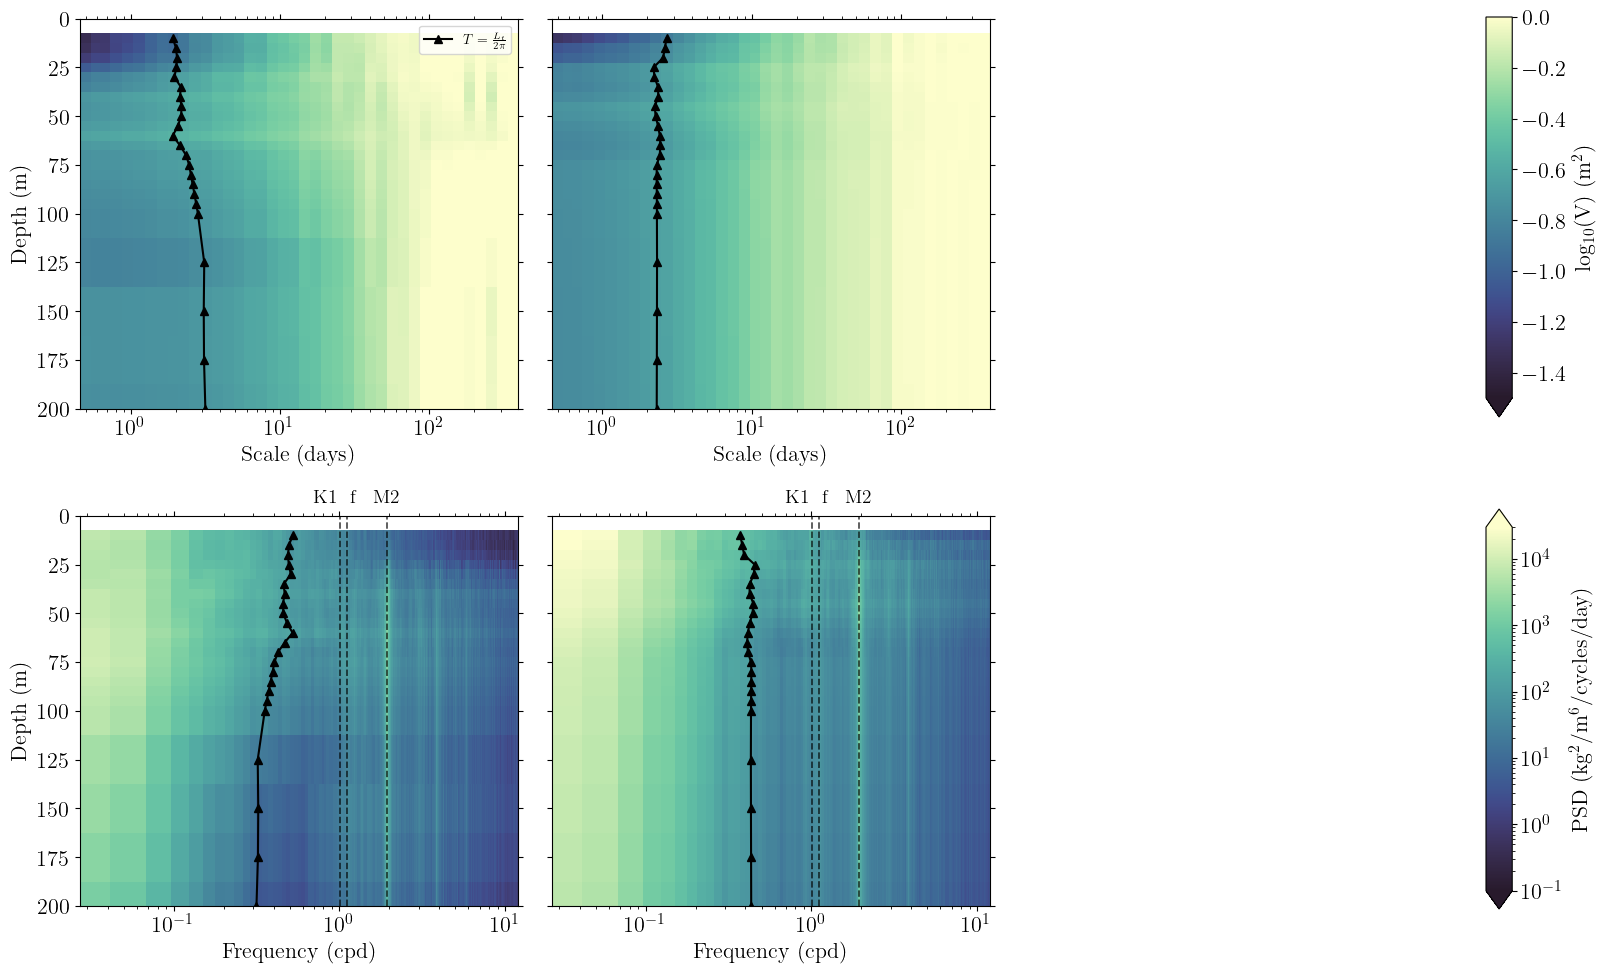

In [65]:
option_data = 'obs'

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=1e-1, vmax=3e4)

# Create meshgrid 
SC_m, D_m = np.meshgrid(L_m[:,0]*(1/24), depth_m) 
SC1, D1 = np.meshgrid(L1_rho[:,0]*(1/24), depth1) 
SC2, D2 = np.meshgrid(L2_rho[:,0]*(1/24), depth2) 

F_m, Df_m = np.meshgrid(f_cpd, depth_m)
F1, Df1 = np.meshgrid(f1_rho * (86400), depth1)
F2, Df2 = np.meshgrid(f2_rho * (86400), depth2)

# Create figure
fig,axes = plt.subplots(2,3,figsize=(15, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

#--- Subplot 1 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax1.pcolormesh(SC_m,D_m,np.log10(V1_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_rho_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax1.pcolormesh(SC1,D1,np.log10(V1_rho.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax1.plot(T1_rho_decor, depth1, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax1.set_xlabel('Scale (days)')
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(0,200)
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)
ax1.legend(loc='upper right',fontsize=10)
ax1.invert_yaxis() 

#--- Subplot 2 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax2.pcolormesh(SC_m,D_m,np.log10(V2_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_rho_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

else: 

    # Plot scale variance 
    pc = ax2.pcolormesh(SC2,D2,np.log10(V2_rho.T),cmap=cmap,shading='auto', vmin=-1.5, vmax=0)

    # Overlay decorrelation frequency markers
    ax2.plot(T2_rho_decor, depth2, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

# Set figure attributes
ax2.set_xlabel('Scale (days)')
ax2.set_yticklabels([])
ax2.set_ylim(0,200)
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)
ax2.invert_yaxis()

#--- Subplot 3 ---#  

if option_data == 'model':

    # Plot scale variance 
    pc = ax3.pcolormesh(SC_m,D_m,np.log10(V3_rho_m.T),cmap=cmap,shading='auto', vmin=-2, vmax=0)

    # Overlay decorrelation frequency markers
    ax3.plot(T3_rho_decor_m, depth_m, 'k^-', markersize=6, label=r'$T = \frac{L_t}{2\pi}$')

    # Set figure attributes
    ax3.set_xlabel('Scale (days)')
    ax3.set_yticklabels([])
    ax3.set_ylim(0,200)
    ax3.set_xscale('log')
    ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
    ax3.tick_params(which='major', length=3.5)
    ax3.tick_params(which='minor', length=2.5)
    ax3.invert_yaxis()

else: 

    ax3.axis('off')

# Set color bar
cax = fig.add_axes([1.0, 0.57, 0.0175, 0.4])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='min') 
cbar.set_label(r'log$_{10}$(V) (m$^2$)')

#--- Subplot 4 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
if option_data == 'model': 

    pc = ax4.pcolormesh(F_m,Df_m,S1_rho_m.T,cmap=cmap,shading='auto',norm=norm)
    ax4.plot(f1_rho_decor_m, depth_m, 'k^-', markersize=6)

else: 

    pc = ax4.pcolormesh(F1,Df1,S1_rho.T,cmap=cmap,shading='auto', norm=norm)
    ax4.plot(f1_rho_decor, depth1, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax4.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax4.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax4.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax4.set_xlabel('Frequency (cpd)')
ax4.set_ylabel('Depth (m)')
ax4.set_xlim(f_cpd[1],f_cpd[-1])
ax4.set_ylim(depth_lim[0],depth_lim[1])
ax4.invert_yaxis() 
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)

#--- Subplot 5 ---#  

if option_data == 'model': 

    pc = ax5.pcolormesh(F_m,Df_m,S2_rho_m.T,cmap=cmap,shading='auto',norm=norm)
    ax5.plot(f2_rho_decor_m, depth_m, 'k^-', markersize=6)

else:

    ax5.pcolormesh(F1,Df1,S2_rho.T,cmap=cmap,shading='auto',norm=norm)
    ax5.plot(f2_rho_decor, depth1, 'k^-', markersize=6)

# Plot the inertial and tidal frequency lines 
ax5.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax5.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
ax5.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

# Set figure attributes
ax5.set_xlabel('Frequency (cpd)')
ax5.set_xlim(f_cpd[1],f_cpd[-1])
ax5.set_ylim(depth_lim[0],depth_lim[1])
ax5.invert_yaxis() 
ax5.set_yticklabels([])
ax5.set_xscale('log')
ax5.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax5.tick_params(which='major', length=3.5)
ax5.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

if option_data == 'model': 

    pc = ax6.pcolormesh(F_m,Df_m,S3_rho_m.T,cmap=cmap,shading='auto',norm=norm)
    ax6.plot(f3_rho_decor_m, depth_m, 'k^-', markersize=6)

    # Plot the inertial and tidal frequency lines 
    ax6.axvline(f1_i, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax6.axvline(f_m2, color='k', linestyle='--', alpha=0.7, linewidth=1.25)
    ax6.axvline(f_k1, color='k', linestyle='--', alpha=0.7, linewidth=1.25)

    # Set figure attributes
    ax6.set_xlabel('Frequency (cpd)')
    ax6.set_xlim(f_cpd[1],f_cpd[-1])
    ax6.set_ylim(depth_lim[0],depth_lim[1])
    ax6.invert_yaxis() 
    ax6.set_yticklabels([])
    ax6.set_xscale('log')
    ax6.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
    ax6.tick_params(which='major', length=3.5)
    ax6.tick_params(which='minor', length=2.5)

else: 

    ax6.axis('off')

# Set color bar
cax = fig.add_axes([1.0, 0.078, 0.0175, 0.4])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Example text positions for top row
ax4.text(f1_i + 0.1, depth_lim[0] - 5, 'f', ha='center', va='bottom', fontsize=14)
ax4.text(f_m2, depth_lim[0] - 5, 'M2', ha='center', va='bottom', fontsize=14)
ax4.text(f_k1 - 0.18, depth_lim[0] - 5, 'K1', ha='center', va='bottom', fontsize=14)

ax5.text(f1_i + 0.1, depth_lim[0] - 5, 'f', ha='center', va='bottom', fontsize=14)
ax5.text(f_m2, depth_lim[0] - 5, 'M2', ha='center', va='bottom', fontsize=14)
ax5.text(f_k1 - 0.18, depth_lim[0] - 5, 'K1', ha='center', va='bottom', fontsize=14)

if option_data == 'model':
    ax6.text(f1_i + 0.1, depth_lim[0] - 5, 'f', ha='center', va='bottom', fontsize=14)
    ax6.text(f_m2, depth_lim[0] - 5, 'M2', ha='center', va='bottom', fontsize=14)
    ax6.text(f_k1 - 0.18, depth_lim[0] - 5, 'K1', ha='center', va='bottom', fontsize=14)

# Display figure
plt.tight_layout()
plt.show()

Read in processed time series of temperature in depth and isopycnal coordinates

In [18]:
#--- MITgcm Data ---# 
filename_ts = PATH + ROOT_mitgcm + "/mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
nc = Dataset(filename_ts, 'r')

# Extract data variables
depth_ts_m = abs(nc.variables['depth'][:])
iso1 = nc.variables['isopycnal1'][:]
iso2 = nc.variables['isopycnal2'][:]
iso3 = nc.variables['isopycnal3'][:]
time_m  =  num2date(nc.variables['time'][:], nc.variables['time'].units,only_use_cftime_datetimes=False)

CT_m = nc.variables['CTemp'][:]
CT_iso1_m = nc.variables['CTemp1_sig'][:]
CT_iso2_m = nc.variables['CTemp2_sig'][:]
CT_iso3_m = nc.variables['CTemp3_sig'][:]

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3345852527.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax2.plot(time_m,CT_iso1_m[idx_iso1,:], '-', linewidth=1.5, color='tab:red',label=f"{iso_levels[0]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso1]))} $\pm$ 15m)")
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3345852527.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax2.plot(time_m,CT_iso1_m[idx_iso2,:], '-', linewidth=1.5, color='tab:green',label=f"{iso_levels[1]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso2]))} $\pm$ 15m)")
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_95434/3345852527.py:40: SyntaxWarning: invalid escape sequenc

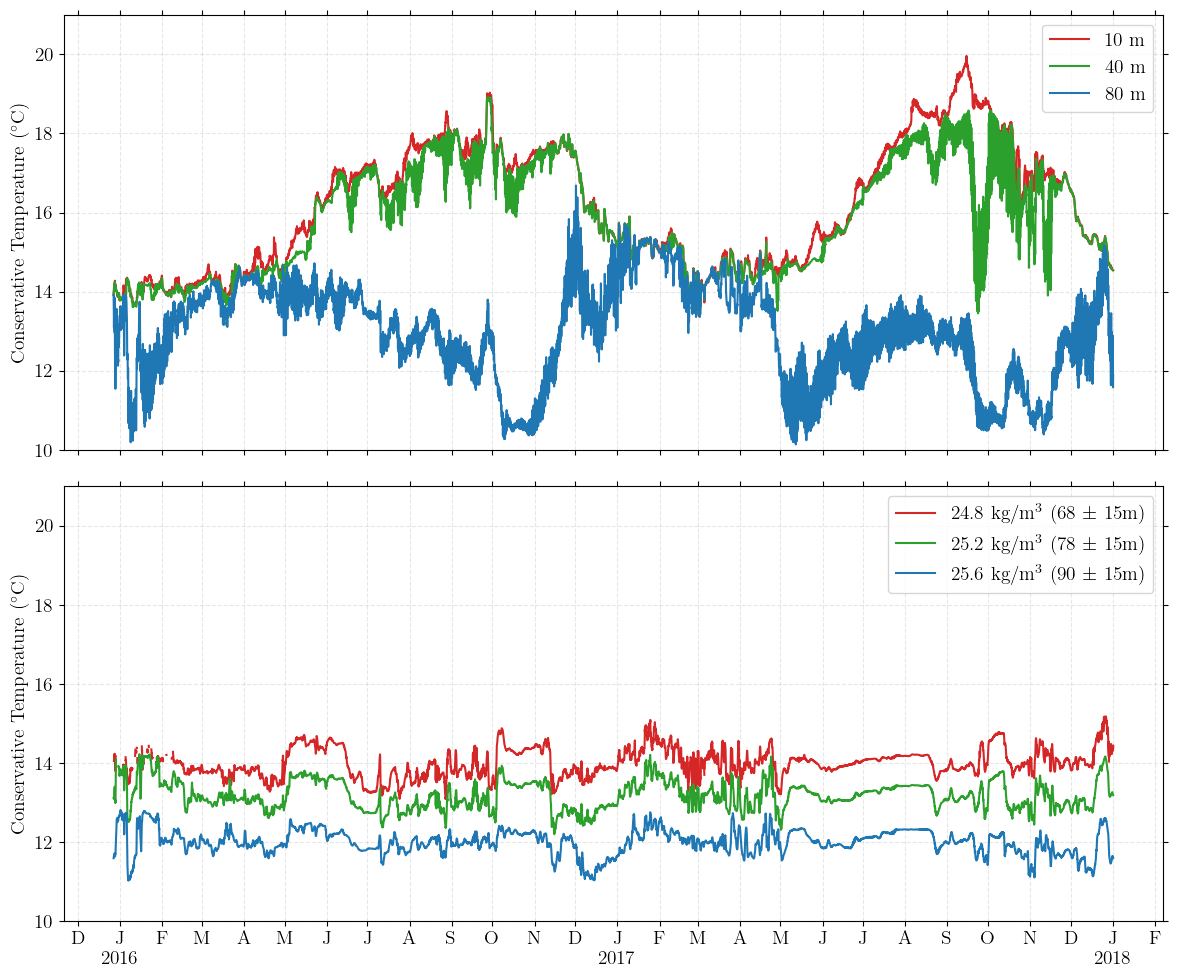

In [ ]:
# Set plotting parameters 
cce_idx = 0
depth_levels = [10,40,80]
iso_levels = [24.80, 25.2, 25.6, 26.2]

# Create figure
fig,axes = plt.subplots(2,1,figsize=(12, 10))
ax1,ax2 = axes.flatten()

#--- Subplot 1 ---#  
idx_depth1 = np.argmin(abs(depth_ts_m - depth_levels[0]))
idx_depth2 = np.argmin(abs(depth_ts_m - depth_levels[1]))
idx_depth3 = np.argmin(abs(depth_ts_m - depth_levels[2]))

# Plot temperature each depth level
ax1.plot(time_m,CT_m[cce_idx, :,idx_depth1], '-', linewidth=1.5, color='tab:red',label=f"{int(depth_levels[0])} m")
ax1.plot(time_m,CT_m[cce_idx, :,idx_depth2], '-', linewidth=1.5, color='tab:green',label=f"{int(depth_levels[1])} m")
ax1.plot(time_m,CT_m[cce_idx, :,idx_depth3], '-', linewidth=1.5, color='tab:blue',label=f"{int(depth_levels[2])} m")

# Set axis attributes
ax1.set_xticklabels([])
ax1.set_ylabel(r'Conservative Temperature ($^\circ$C)')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_ylim(10,21)
ax1.legend()

#--- Subplot 2 ---#  
idx_iso1 = np.argmin(abs(iso1 - iso_levels[0]))
idx_iso2 = np.argmin(abs(iso2 - iso_levels[1]))
idx_iso3 = np.argmin(abs(iso3 - iso_levels[2]))

# Plot temperature each depth level
ax2.plot(time_m,CT_iso1_m[idx_iso1,:], '-', linewidth=1.5, color='tab:red',label=f"{iso_levels[0]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso1]))} $\pm$ 15m)")
ax2.plot(time_m,CT_iso1_m[idx_iso2,:], '-', linewidth=1.5, color='tab:green',label=f"{iso_levels[1]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso2]))} $\pm$ 15m)")
ax2.plot(time_m,CT_iso1_m[idx_iso3,:], '-', linewidth=1.5, color='tab:blue',label=f"{iso_levels[2]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso3]))} $\pm$ 15m)")

# Set axis attributes
ax2.set_ylabel(r'Conservative Temperature ($^\circ$C)')
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.set_ylim(10,21)
ax2.legend()

# Display 
plt.tight_layout()
plt.show()

In [ ]:
# Set plotting parameters 
cce_idx = 0
depth_levels = [10,40,80]
iso_levels = [24.80, 25.2, 25.6, 26.2]

# Create figure
fig,axes = plt.subplots(2,1,figsize=(12, 10))
ax1,ax2 = axes.flatten()

#--- Subplot 1 ---#  
idx_depth1 = np.argmin(abs(depth_ts_m - depth_levels[0]))
idx_depth2 = np.argmin(abs(depth_ts_m - depth_levels[1]))
idx_depth3 = np.argmin(abs(depth_ts_m - depth_levels[2]))

# Plot temperature each depth level
ax1.plot(time_m,CT_m[cce_idx, :,idx_depth1], '-', linewidth=1.5, color='tab:red',label=f"{int(depth_levels[0])} m")
ax1.plot(time_m,CT_m[cce_idx, :,idx_depth2], '-', linewidth=1.5, color='tab:green',label=f"{int(depth_levels[1])} m")
ax1.plot(time_m,CT_m[cce_idx, :,idx_depth3], '-', linewidth=1.5, color='tab:blue',label=f"{int(depth_levels[2])} m")

# Set axis attributes
ax1.set_xticklabels([])
ax1.set_ylabel(r'Conservative Temperature ($^\circ$C)')
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_ylim(10,21)
ax1.legend()

#--- Subplot 1 ---#  
idx_iso1 = np.argmin(abs(iso1 - iso_levels[0]))
idx_iso2 = np.argmin(abs(iso2 - iso_levels[1]))
idx_iso3 = np.argmin(abs(iso3 - iso_levels[2]))

# Plot temperature each depth level
ax2.plot(time_m,CT_iso1_m[idx_iso1,:], '-', linewidth=1.5, color='tab:red',label=f"{iso_levels[0]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso1]))} $\pm$ 15m)")
ax2.plot(time_m,CT_iso1_m[idx_iso2,:], '-', linewidth=1.5, color='tab:green',label=f"{iso_levels[1]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso2]))} $\pm$ 15m)")
ax2.plot(time_m,CT_iso1_m[idx_iso3,:], '-', linewidth=1.5, color='tab:blue',label=f"{iso_levels[2]} kg/m$^3$ ({abs(int(meanZ1_iso_m[idx_iso3]))} $\pm$ 15m)")

# Set axis attributes
ax2.set_ylabel(r'Conservative Temperature ($^\circ$C)')
ax2.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.set_ylim(10,21)
ax2.legend()

# Display 
plt.tight_layout()
plt.show()

(16, 17661)